### 아래 분석에서 만든 그래프들은 excel에서 다시 그려서 보고서, PPT에 사용하였음

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [ ]:
df = pd.read_csv('./data/hacktho_FF_final.csv')

# 군집별 범주형 변수 분포 분석

In [3]:
def analyze_cluster_demographics(df, cluster_col='비이자수익 군집'):
    """군집별 기본 인구통계학적 변수 분포 분석"""
    
    print("=== 1단계: 군집별 범주형 변수 분포 분석 ===\n")
    
    # 주요 범주형 변수 리스트
    categorical_vars = ['연령대', '성별', '광역시도', '시군구', 
                       '모바일뱅킹 등록 여부', '오픈뱅킹 가입 여부', 
                       '급여이체 등록 여부', '외국인여부']
    
    # 1) 군집별 각 변수의 교차표 및 비율 분석
    for var in categorical_vars:
        if var in df.columns:
            print(f"\n=== 군집별 {var} 분포 ===")
            
            # 교차표 (빈도수)
            crosstab_count = pd.crosstab(df[cluster_col], df[var], margins=True)
            print("📊 빈도수:")
            print(crosstab_count)
            
            # 비율표 (%)
            crosstab_pct = pd.crosstab(df[cluster_col], df[var], normalize='index') * 100
            print("\n📊 비율(%):")
            print(crosstab_pct.round(1))
            
            # 각 군집별 최빈값
            print("\n📊 군집별 최빈값:")
            for cluster in sorted(df[cluster_col].unique()):
                cluster_data = df[df[cluster_col] == cluster]
                if len(cluster_data) > 0:
                    mode_val = cluster_data[var].mode().iloc[0] if not cluster_data[var].mode().empty else 'N/A'
                    pct = (cluster_data[var] == mode_val).mean() * 100
                    print(f"  군집 {cluster}: {mode_val} ({pct:.1f}%)")
            
            print("-" * 60)

# 실행
analyze_cluster_demographics(df)

=== 1단계: 군집별 범주형 변수 분포 분석 ===


=== 군집별 연령대 분포 ===
📊 빈도수:
연령대         10대  10대미만     20대     30대     40대     50대     60대     70대  80대이상  \
비이자수익 군집                                                                        
0         29558   3020  143172  276940  298609  260663  221558  130641  63701   
1          8818      1   51990   40552   46715   55789   54589   24501   6351   
2          4109      5   37154   38822   50505   61366   52710   19398   4570   
3           476     75    2930    8444   18100   29615   33008   12857   1714   
All       42961   3101  235246  364758  413929  407433  361865  187397  76336   

연령대       연령미상      All  
비이자수익 군집                 
0          480  1428342  
1           14   289320  
2            7   268646  
3            0   107219  
All        501  2093527  

📊 비율(%):
연령대       10대  10대미만   20대   30대   40대   50대   60대   70대  80대이상  연령미상
비이자수익 군집                                                             
0         2.1    0.2  10.0  19.4  20.9  18

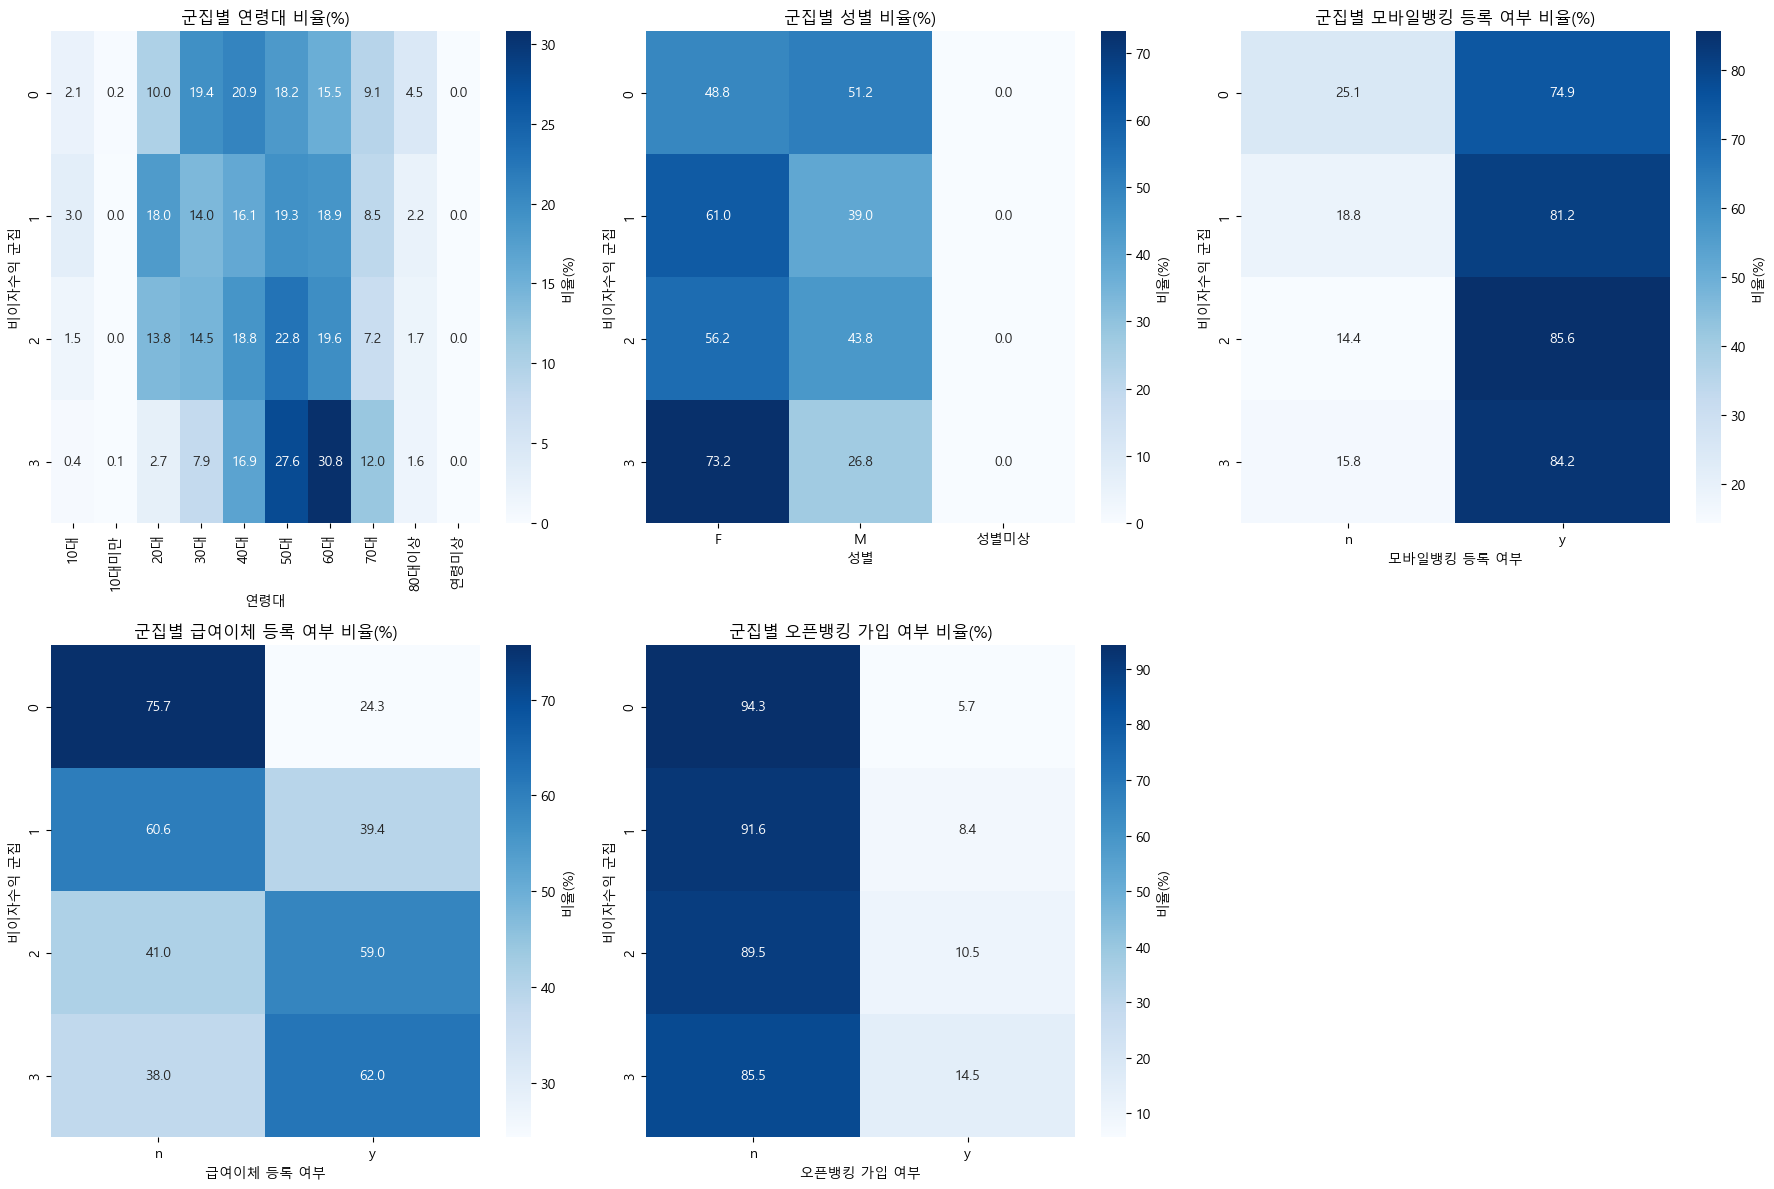

In [4]:
def plot_cluster_heatmaps(df, cluster_col='비이자수익 군집'):
    """군집별 변수들의 비율을 히트맵으로 시각화"""
    
    categorical_vars = ['연령대', '성별', '모바일뱅킹 등록 여부', 
                       '급여이체 등록 여부', '오픈뱅킹 가입 여부']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()
    
    for i, var in enumerate(categorical_vars):
        if var in df.columns and i < len(axes):
            # 비율 교차표 생성
            crosstab_pct = pd.crosstab(df[cluster_col], df[var], normalize='index') * 100
            
            # 히트맵 생성
            sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='Blues',
                       ax=axes[i], cbar_kws={'label': '비율(%)'})
            axes[i].set_title(f'군집별 {var} 비율(%)')
            axes[i].set_xlabel(var)
            axes[i].set_ylabel(cluster_col)
    
    # 빈 subplot 제거
    for j in range(len(categorical_vars), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# 실행
plot_cluster_heatmaps(df)

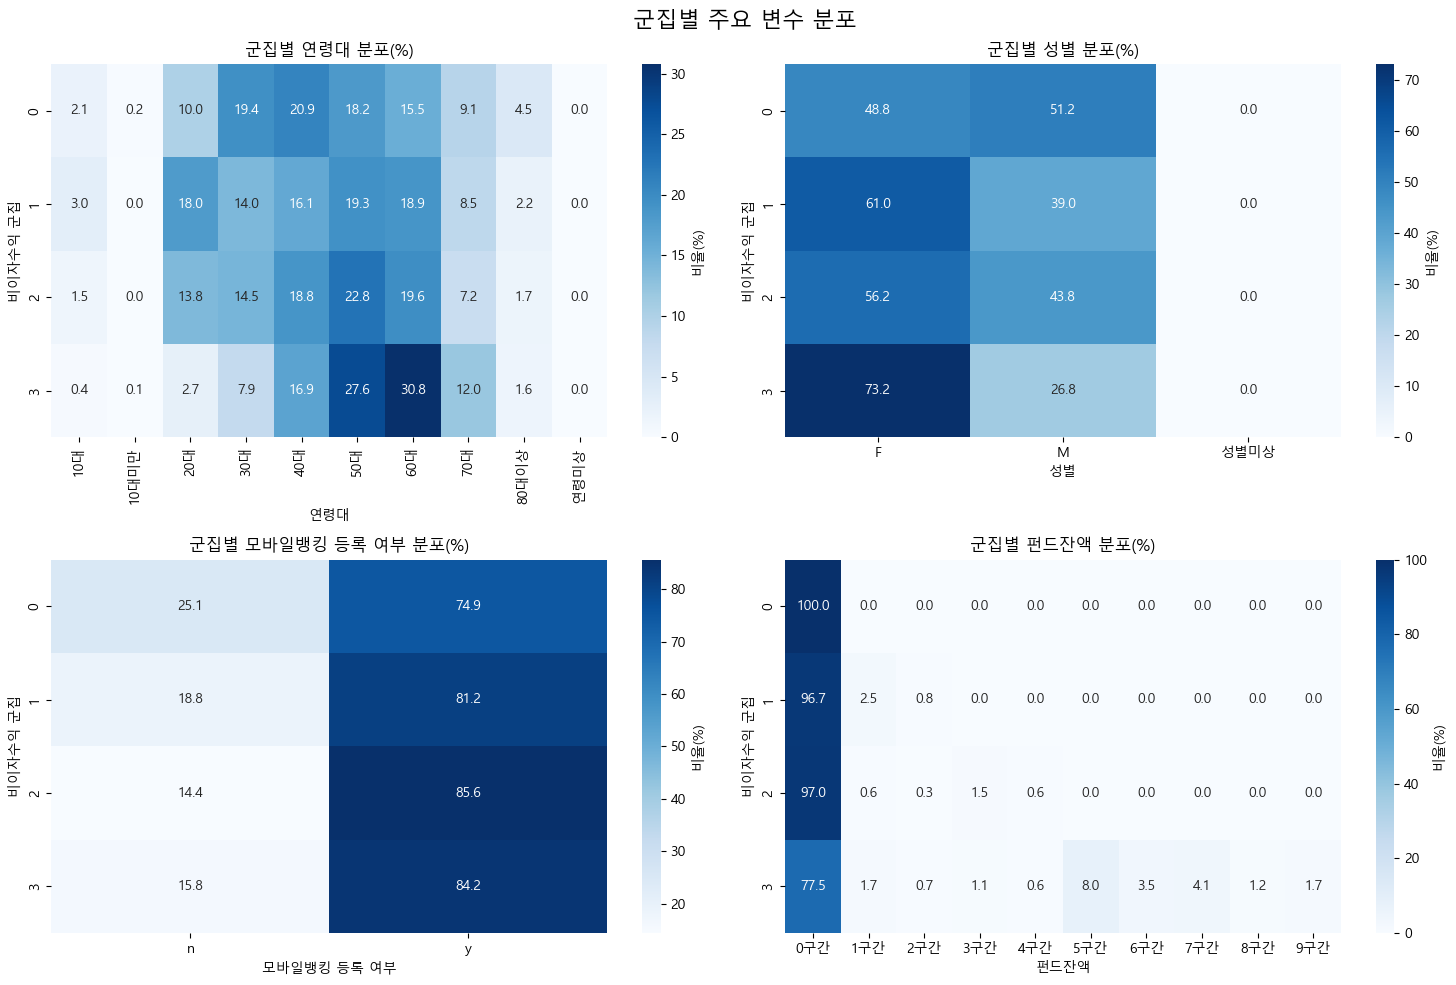

In [5]:
def visualize_cluster_distribution(df, cluster_col='비이자수익 군집'):
    """군집별 주요 변수 시각화"""
    
    
    # 주요 변수들
    key_vars = ['연령대', '성별', '모바일뱅킹 등록 여부', '펀드잔액']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('군집별 주요 변수 분포', fontsize=16)
    
    for i, var in enumerate(key_vars):
        row = i // 2
        col = i % 2
        
        if var in df.columns:
            # 교차표 생성
            crosstab = pd.crosstab(df[cluster_col], df[var], normalize='index') * 100
            
            # 히트맵 생성
            sns.heatmap(crosstab, annot=True, fmt='.1f', cmap='Blues', 
                       ax=axes[row, col], cbar_kws={'label': '비율(%)'})
            axes[row, col].set_title(f'군집별 {var} 분포(%)')
            axes[row, col].set_xlabel(var)
            axes[row, col].set_ylabel('비이자수익 군집')
    
    plt.tight_layout()
    plt.show()

# 실행
visualize_cluster_distribution(df)

<Figure size 1200x600 with 0 Axes>

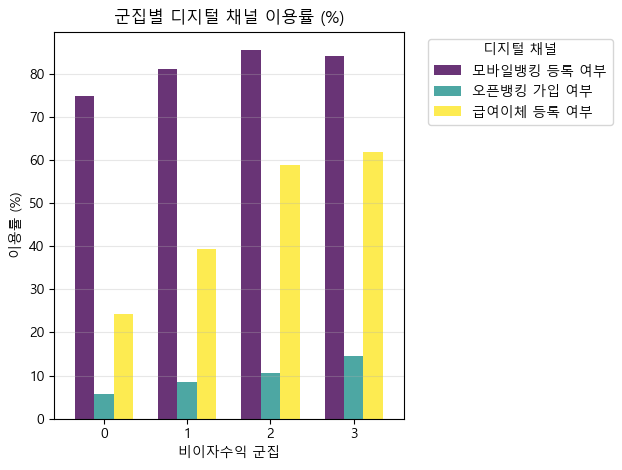

In [6]:
def plot_digital_channel_usage(df, cluster_col='비이자수익 군집'):
    """디지털 채널 이용률 시각화"""
    
    # 한글 폰트 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    # 디지털 채널 이용률 계산
    digital_rates = df.groupby(cluster_col).agg({
        '모바일뱅킹 등록 여부': lambda x: (x == 'y').mean() * 100,
        '오픈뱅킹 가입 여부': lambda x: (x == 'y').mean() * 100,
        '급여이체 등록 여부': lambda x: (x == 'y').mean() * 100
    })
    
    # 막대 차트
    plt.figure(figsize=(12, 6))
    digital_rates.plot(kind='bar', rot=0, colormap='viridis', alpha=0.8, width=0.7)
    plt.title('군집별 디지털 채널 이용률 (%)')
    plt.ylabel('이용률 (%)')
    plt.xlabel('비이자수익 군집')
    plt.legend(title='디지털 채널', bbox_to_anchor=(1.05, 1))
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 실행
plot_digital_channel_usage(df)

## 그래프 분석

- **노드 수치**  
  각 군집 내 고객이 특정 상품을 이용하는 비율을 의미합니다.  
  예: 방카슈랑스 노드에 `10%`라고 표시되어 있다면, **해당 군집 고객 중 10%가 방카슈랑스를 이용**함을 의미합니다.

- **화살표 (A → B)**  
  상품 A를 이용하는 고객 중, 동시에 상품 B도 이용하는 고객의 비율을 나타냅니다.  
  예: `방카슈랑스 → 펀드 (40%)`라면, **방카슈랑스를 이용하는 고객 중 40%가 펀드도 이용**하고 있음을 뜻합니다.

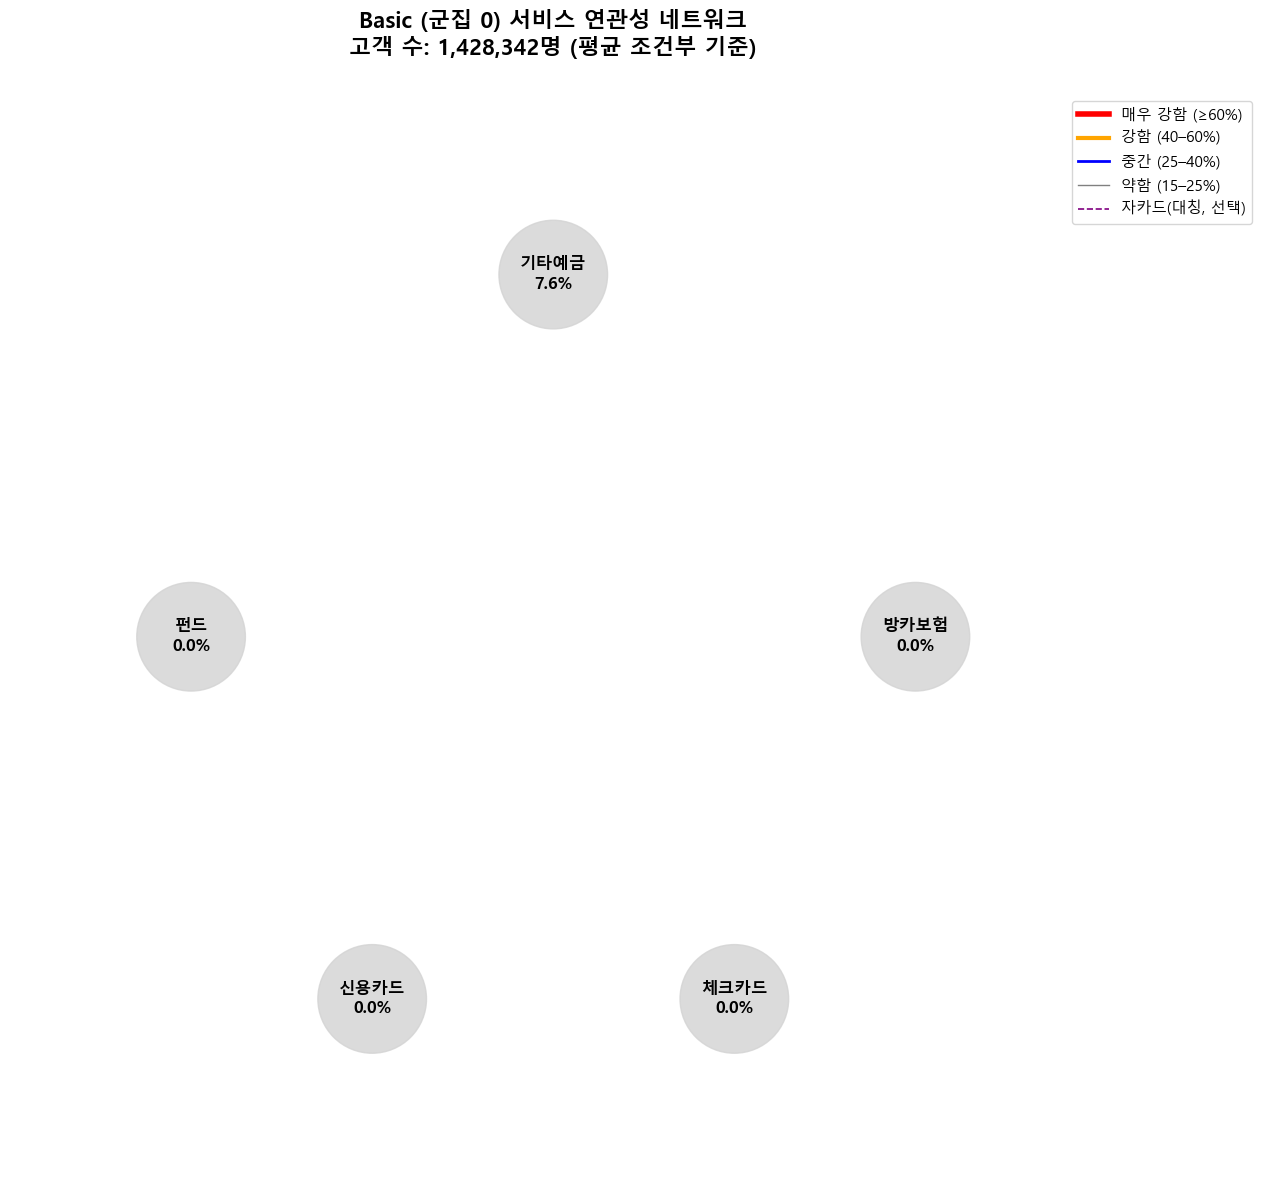

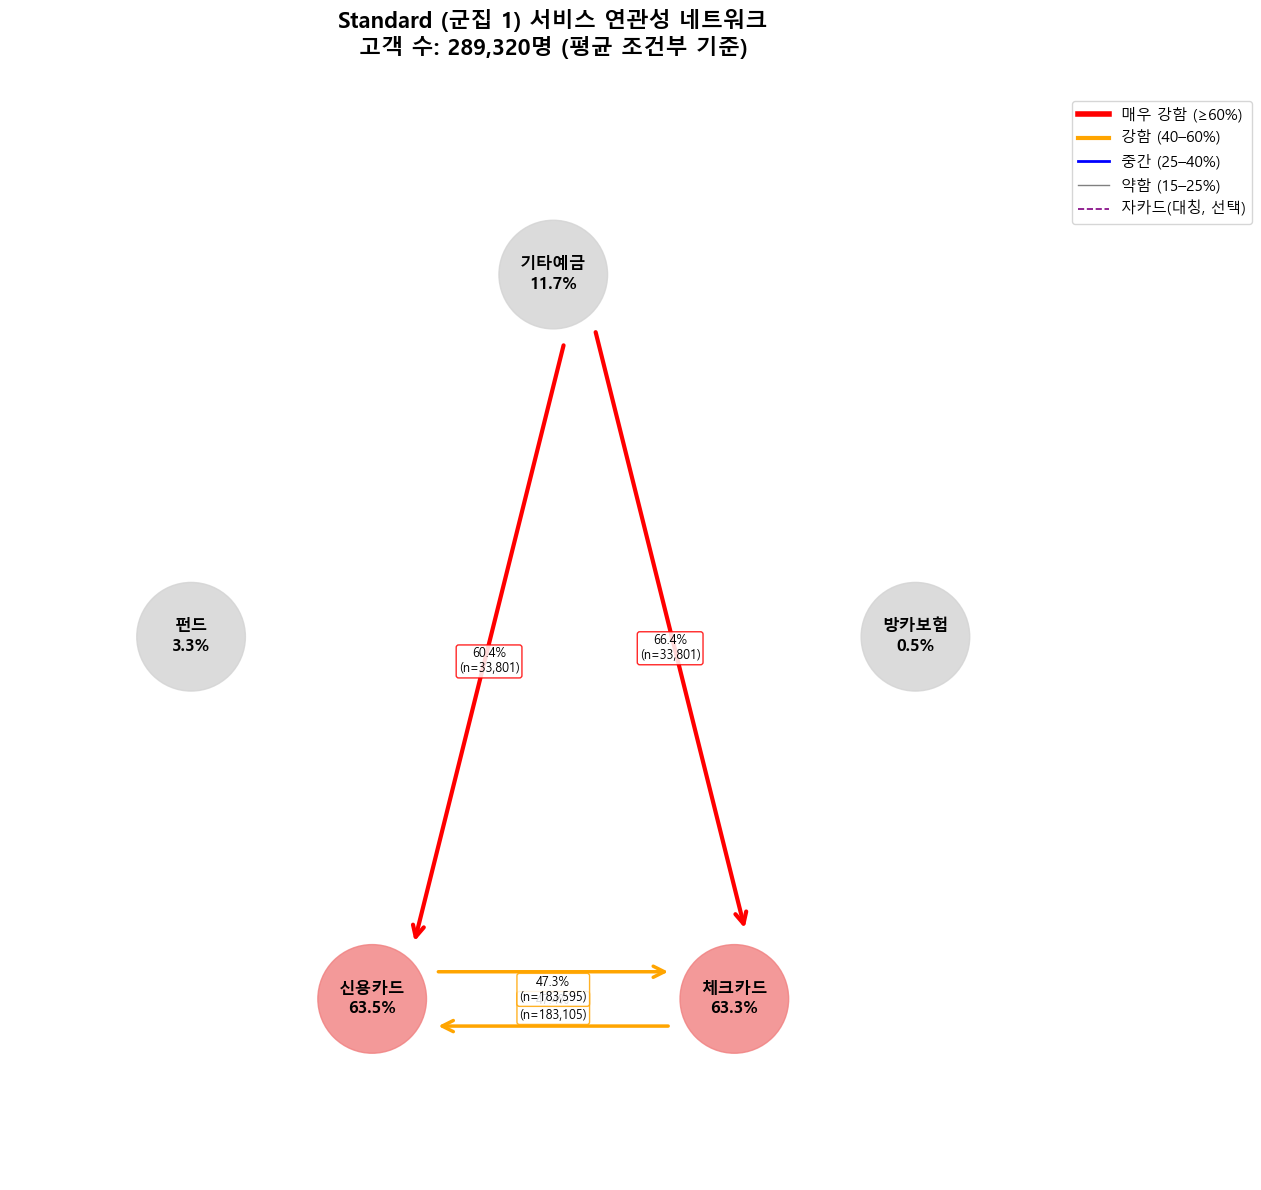

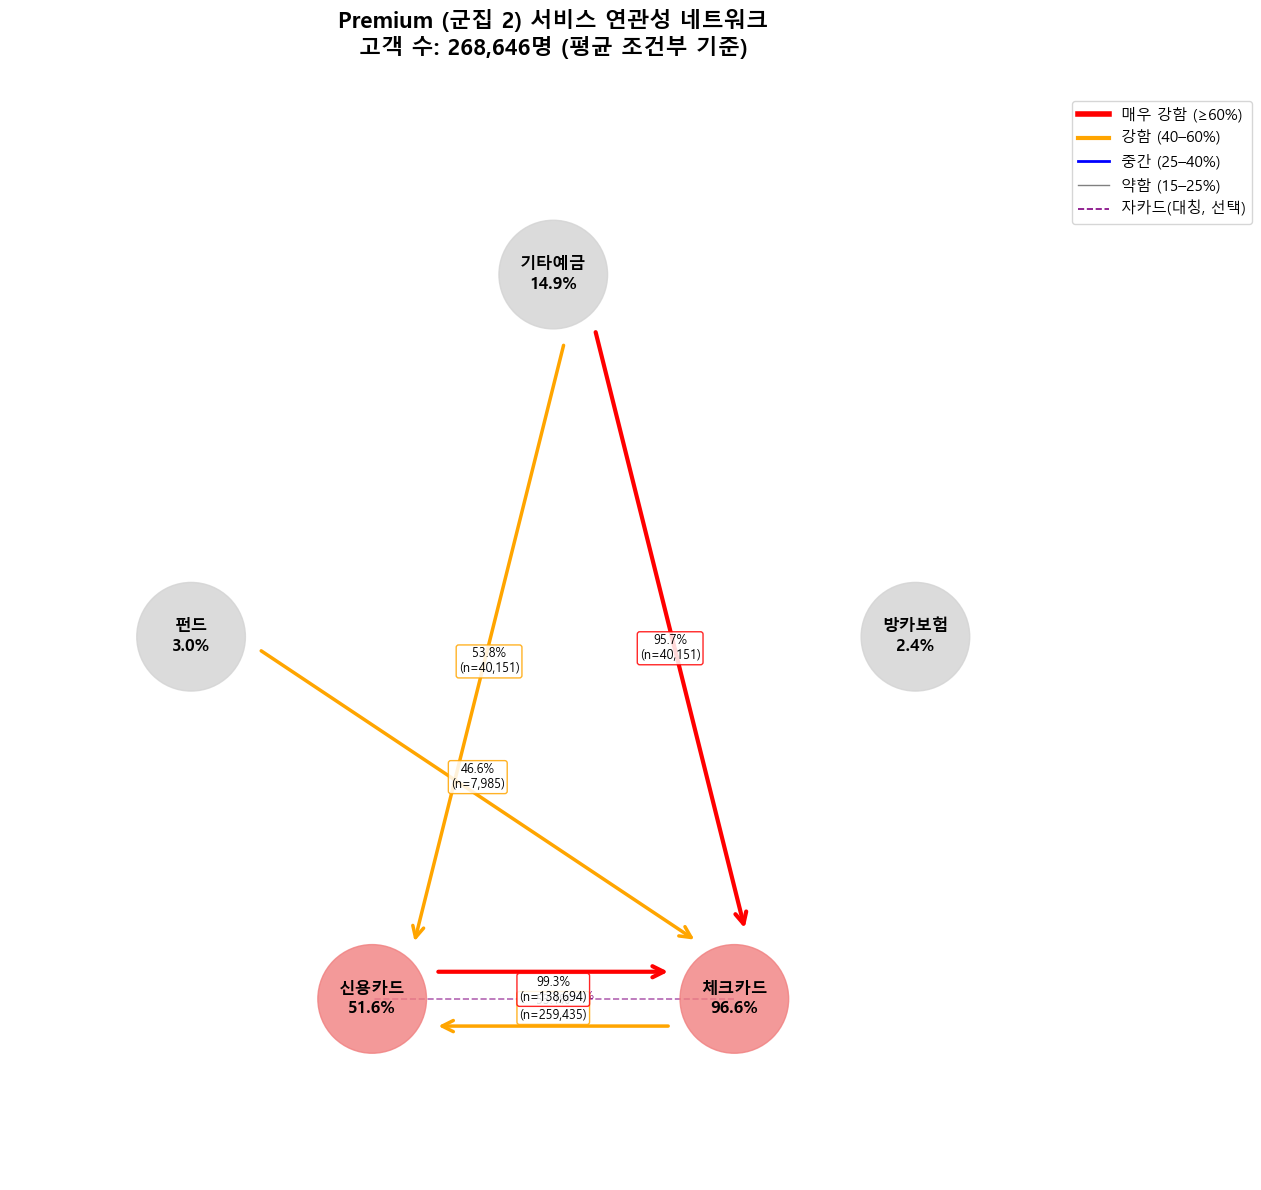

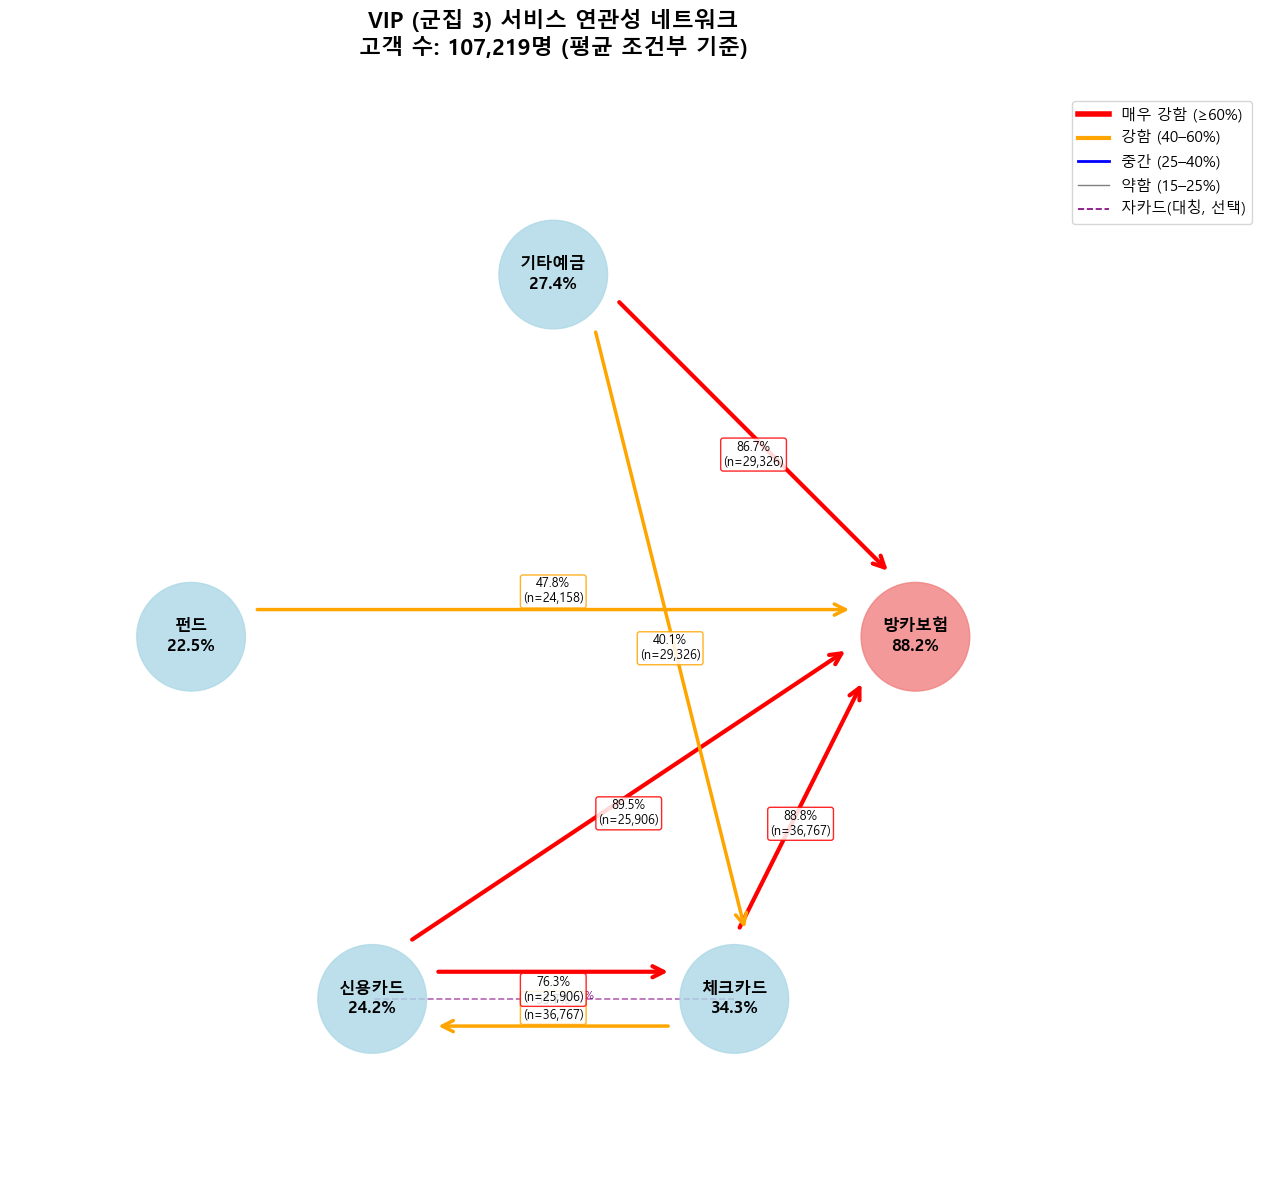

In [7]:
def create_cluster_network_avg(
    df,
    cluster_col='비이자수익 군집',
    min_connection_rate=40,      
    min_support=10,             # 조건부 모수(A사용자 수)가 이보다 작으면 표시 안 함
    use_jaccard=True            # True면 자카드로 대칭 링크도 추가 표기 가능
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyArrowPatch
    import pandas as pd

    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    all_services = ['펀드잔액', '방카슈랑스잔액', '체크카드 거래액 합계', '신용카드 거래액 합계', '기타예금평잔']
    services = [s for s in all_services if s in df.columns]

    short = {'펀드잔액':'펀드','방카슈랑스잔액':'방카보험','체크카드 거래액 합계':'체크카드','신용카드 거래액 합계':'신용카드','기타예금평잔':'기타예금'}
    names = {0:'Basic',1:'Standard',2:'Premium',3:'VIP'}

    pos = {'기타예금평잔': (0, 2), '펀드잔액': (-2, 0), '방카슈랑스잔액': (2, 0),
           '신용카드 거래액 합계': (-1, -2), '체크카드 거래액 합계': (1, -2)}

    for c in sorted(df[cluster_col].unique()):
        d = df[df[cluster_col]==c].copy()
        title = f"{names.get(c,f'군집{c}')} (군집 {c}) 서비스 연관성 네트워크\n고객 수: {len(d):,}명 (평균 조건부 기준)"
        plt.figure(figsize=(16,12))
        ax = plt.gca()

        # 사용여부 Boolean
        used = {s: (d[s] != '0구간') for s in services}
        usage_rate = {s: used[s].mean()*100 for s in services}

        # 노드
        for s in services:
            if s not in pos: continue
            x,y = pos[s]
            ur = usage_rate[s]
            color = 'lightcoral' if ur>=50 else ('lightblue' if ur>=20 else 'lightgray')
            ax.add_patch(plt.Circle((x,y), 0.3, color=color, alpha=0.8, zorder=3))
            ax.text(x, y, f"{short.get(s,s)}\n{ur:.1f}%", ha='center', va='center', fontsize=12, fontweight='bold', zorder=4)

        # 엣지: 평균 조건부 P(B|A)
        drawn=set()
        for a in services:
            for b in services:
                if a==b or (a,b) in drawn or (b,a) in drawn: 
                    continue
                if a not in pos or b not in pos: 
                    continue

                A = used[a]; B = used[b]
                nA = A.sum(); nB = B.sum()
                nAB = (A & B).sum()

                # 조건부
                p_b_given_a = (nAB / nA * 100) if nA>0 else 0.0
                p_a_given_b = (nAB / nB * 100) if nB>0 else 0.0

                # (선택) 자카드
                jaccard = (nAB / (A|B).sum()*100) if (A|B).sum()>0 else 0.0

                # 지지도 확인
                a_ok = (p_b_given_a>=min_connection_rate) and (nA>=min_support)
                b_ok = (p_a_given_b>=min_connection_rate) and (nB>=min_support)

                if not (a_ok or b_ok or (use_jaccard and jaccard>=min_connection_rate)):
                    continue

                x1,y1 = pos[a]; x2,y2 = pos[b]
                dx,dy = x2-x1, y2-y1
                L = (dx**2+dy**2)**0.5
                ux,uy = dx/L, dy/L
                px,py = -uy*0.15, ux*0.15

                start1=(x1+ux*0.35, y1+uy*0.35); end1=(x2-ux*0.35, y2-uy*0.35)
                start2=(x2-ux*0.35, y2-uy*0.35); end2=(x1+ux*0.35, y1+uy*0.35)

                def style(pct):
                    if pct>=60: return ('red',3.0)
                    if pct>=40: return ('orange',2.5)
                    if pct>=25: return ('blue',2.0)
                    return ('gray',1.5)

                # support 기반 투명도(신뢰도)
                def alpha_from_support(n):
                    # 0.2 ~ 1.0 사이로 스케일
                    return max(0.2, min(1.0, n/ (min_support*2)))

                # A→B
                if a_ok:
                    col,w = style(p_b_given_a)
                    s = (start1[0]+px, start1[1]+py); e = (end1[0]+px, end1[1]+py)
                    ax.add_patch(FancyArrowPatch(s, e, arrowstyle='->', mutation_scale=20,
                                                 color=col, linewidth=w, alpha=alpha_from_support(nA), zorder=2))
                    mx,my = (s[0]+e[0])/2, (s[1]+e[1])/2
                    ax.text(mx, my+0.10, f"{p_b_given_a:.1f}%\n(n={nA:,})", ha='center', va='center', fontsize=9,
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85, edgecolor=col), zorder=5)

                # B→A
                if b_ok:
                    col,w = style(p_a_given_b)
                    s = (start2[0]-px, start2[1]-py); e = (end2[0]-px, end2[1]-py)
                    ax.add_patch(FancyArrowPatch(s, e, arrowstyle='->', mutation_scale=20,
                                                 color=col, linewidth=w, alpha=alpha_from_support(nB), zorder=2))
                    mx,my = (s[0]+e[0])/2, (s[1]+e[1])/2
                    ax.text(mx, my-0.10, f"{p_a_given_b:.1f}%\n(n={nB:,})", ha='center', va='center', fontsize=9,
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85, edgecolor=col), zorder=5)

                # (선택) 대칭 링크 표기 – 얇은 점선 등으로
                if use_jaccard and jaccard>=min_connection_rate:
                    ax.plot([x1,x2],[y1,y2], linestyle='--', linewidth=1.2, alpha=0.6, color='purple', zorder=1)
                    ax.text((x1+x2)/2, (y1+y2)/2, f"J={jaccard:.1f}%", color='purple', fontsize=8)

                drawn.add((a,b))

        ax.set_xlim(-3,3); ax.set_ylim(-3,3)
        ax.set_aspect('equal'); ax.axis('off')
        plt.title(title, fontsize=16, fontweight='bold', pad=28)

        legend = [
            plt.Line2D([0],[0], color='red', linewidth=4, label='매우 강함 (≥60%)'),
            plt.Line2D([0],[0], color='orange', linewidth=3, label='강함 (40–60%)'),
            plt.Line2D([0],[0], color='blue', linewidth=2, label='중간 (25–40%)'),
            plt.Line2D([0],[0], color='gray', linewidth=1, label='약함 (15–25%)'),
            plt.Line2D([0],[0], linestyle='--', color='purple', linewidth=1.2, label='자카드(대칭, 선택)'),
        ]
        plt.legend(handles=legend, loc='upper right', fontsize=11, bbox_to_anchor=(1.15,1.0))
        plt.tight_layout()
        plt.show()


create_cluster_network_avg(df)

In [29]:
def create_cluster_network_avg_save(
    df,
    cluster_col='비이자수익 군집',
    min_connection_rate=40,      # 화살표(조건부 확률) 표시 임계치(%)
    min_support=10,              # 지원수(분모) 최소 n
    use_jaccard=True,            # 자카드(대칭) 표시 여부
    save_path_prefix='cluster_network'  # 저장 파일명 접두사
):
    """
    군집별 서비스 이용 연관성(조건부 확률 & 자카드) 네트워크를 그려 PNG로 저장합니다.
    노드: 서비스 사용률(%)
    엣지: P(B|A)와 P(A|B) 조건부 확률(방향 화살표), 필요 시 자카드(점선)
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyArrowPatch

    # 한글 폰트/마이너스 표시
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    # 후보 서비스(실제 존재하는 컬럼만 사용)
    all_services = ['펀드잔액', '방카슈랑스잔액', '체크카드 거래액 합계', '신용카드 거래액 합계', '기타예금평잔']
    services = [s for s in all_services if s in df.columns]
    if len(services) < 2:
        raise ValueError("네트워크를 그리려면 2개 이상의 서비스 컬럼이 필요합니다.")

    # 축약명
    short = {
        '펀드잔액': '펀드',
        '방카슈랑스잔액': '방카보험',
        '체크카드 거래액 합계': '체크카드',
        '신용카드 거래액 합계': '신용카드',
        '기타예금평잔': '기타예금'
    }

    # 군집명 매핑(없으면 기본)
    names = {0: 'Basic', 1: 'Standard', 2: 'Premium', 3: 'VIP'}

    # 노드 위치(존재하는 것만 사용)
    base_pos = {
        '기타예금평잔': (0, 2),
        '펀드잔액': (-2, 0),
        '방카슈랑스잔액': (2, 0),
        '신용카드 거래액 합계': (-1, -2),
        '체크카드 거래액 합계': (1, -2)
    }
    pos = {k: v for k, v in base_pos.items() if k in services}

    # 각 군집별 도식
    for c in sorted(df[cluster_col].dropna().unique()):
        d = df[df[cluster_col] == c].copy()
        n_customers = len(d)
        if n_customers == 0:
            continue

        title = f"{names.get(c, f'군집 {c}')}: 서비스 연관성 네트워크\n고객 수: {n_customers:,}명 (조건부 기준)"

        fig = plt.figure(figsize=(16, 12))
        ax = plt.gca()

        # 사용여부(0구간 제외) → 불리언 시리즈
        used = {s: (d[s] != '0구간') for s in services}
        usage_rate = {s: used[s].mean() * 100 if n_customers > 0 else 0.0 for s in services}

        # 노드 그리기
        for s in services:
            if s not in pos:
                continue
            x, y = pos[s]
            ur = usage_rate[s]

            # 사용률에 따른 색
            if ur >= 50:
                color = 'lightcoral'
            elif ur >= 20:
                color = 'lightblue'
            else:
                color = 'lightgray'

            circle = plt.Circle((x, y), 0.3, color=color, alpha=0.85, zorder=3)
            ax.add_patch(circle)
            ax.text(
                x, y,
                f"{short.get(s, s)}\n{ur:.1f}%",
                ha='center', va='center',
                fontsize=12, fontweight='bold', zorder=4
            )

        # 엣지 스타일 함수
        def style(pct):
            if pct >= 60:
                return ('red', 3.0)
            if pct >= 40:
                return ('orange', 2.5)
            if pct >= 25:
                return ('blue', 2.0)
            return ('gray', 1.5)

        # 지원수에 따른 alpha
        def alpha_from_support(n):
            return max(0.2, min(1.0, n / (min_support * 2)))

        drawn = set()

        # 엣지(조건부 확률 + 자카드)
        for i, a in enumerate(services):
            for b in services[i + 1:]:
                if a not in pos or b not in pos:
                    continue

                A = used[a]
                B = used[b]
                nA = int(A.sum())
                nB = int(B.sum())
                nAB = int((A & B).sum())
                nAUB = int((A | B).sum())

                # 조건부 확률 P(B|A), P(A|B) [%]
                p_b_given_a = (nAB / nA * 100) if nA > 0 else 0.0
                p_a_given_b = (nAB / nB * 100) if nB > 0 else 0.0

                # 자카드(대칭) [%]
                jaccard = (nAB / nAUB * 100) if nAUB > 0 else 0.0

                # 임계 조건
                a_ok = (p_b_given_a >= min_connection_rate) and (nA >= min_support)
                b_ok = (p_a_given_b >= min_connection_rate) and (nB >= min_support)
                j_ok = use_jaccard and (jaccard >= min_connection_rate)

                if not (a_ok or b_ok or j_ok):
                    continue

                x1, y1 = pos[a]
                x2, y2 = pos[b]
                dx, dy = x2 - x1, y2 - y1
                L = (dx ** 2 + dy ** 2) ** 0.5
                if L == 0:
                    continue
                ux, uy = dx / L, dy / L

                # 평행 이동(겹침 방지용)
                px, py = -uy * 0.15, ux * 0.15

                # A→B
                if a_ok:
                    col, w = style(p_b_given_a)
                    s_pt = (x1 + ux * 0.35 + px, y1 + uy * 0.35 + py)
                    e_pt = (x2 - ux * 0.35 + px, y2 - uy * 0.35 + py)

                    ax.add_patch(FancyArrowPatch(
                        s_pt, e_pt, arrowstyle='->', mutation_scale=20,
                        color=col, linewidth=w, alpha=alpha_from_support(nA), zorder=2
                    ))

                    # 라벨 위치(중점)
                    mx = (s_pt[0] + e_pt[0]) / 2
                    my = (s_pt[1] + e_pt[1]) / 2
                    ax.text(
                        mx, my + 0.10,
                        f"{p_b_given_a:.1f}%\n(n={nA:,})",
                        ha='center', va='center', fontsize=9,
                        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85, edgecolor=col),
                        zorder=5
                    )

                # B→A
                if b_ok:
                    col, w = style(p_a_given_b)
                    s_pt = (x2 - ux * 0.35 - px, y2 - uy * 0.35 - py)
                    e_pt = (x1 + ux * 0.35 - px, y1 + uy * 0.35 - py)

                    ax.add_patch(FancyArrowPatch(
                        s_pt, e_pt, arrowstyle='->', mutation_scale=20,
                        color=col, linewidth=w, alpha=alpha_from_support(nB), zorder=2
                    ))

                    mx = (s_pt[0] + e_pt[0]) / 2
                    my = (s_pt[1] + e_pt[1]) / 2
                    ax.text(
                        mx, my - 0.10,
                        f"{p_a_given_b:.1f}%\n(n={nB:,})",
                        ha='center', va='center', fontsize=9,
                        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85, edgecolor=col),
                        zorder=5
                    )

                # 자카드(대칭) 점선
                if j_ok:
                    ax.plot([x1, x2], [y1, y2], linestyle='--', linewidth=1.2, alpha=0.6, color='purple', zorder=1)
                    ax.text(
                        (x1 + x2) / 2, (y1 + y2) / 2,
                        f"J={jaccard:.1f}%", color='purple', fontsize=8, zorder=5
                    )

                drawn.add((a, b))

        # 축/타이틀/범례
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect('equal')
        ax.axis('off')
        plt.title(title, fontsize=16, fontweight='bold', pad=28)

        # 범례(가짜 선으로 스타일만 표현)
        legend = [
            plt.Line2D([0], [0], color='red', linewidth=4, label='매우 강함 (≥60%)'),
            plt.Line2D([0], [0], color='orange', linewidth=3, label='강함 (40–60%)'),
            plt.Line2D([0], [0], color='blue', linewidth=2, label='중간 (25–40%)'),
            plt.Line2D([0], [0], color='gray', linewidth=1, label='약함 (<25%)'),
            plt.Line2D([0], [0], linestyle='--', color='purple', linewidth=1.2, label='자카드(대칭, 선택)'),
        ]
        plt.legend(handles=legend, loc='upper right', fontsize=11, bbox_to_anchor=(1.15, 1.0))
        plt.tight_layout()

        # 저장
        filename = f"{save_path_prefix}_군집{c}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ 저장 완료: {filename}")

        # 화면 표시
        plt.show()
        plt.close()


✅ 저장 완료: cluster_network_군집0.png


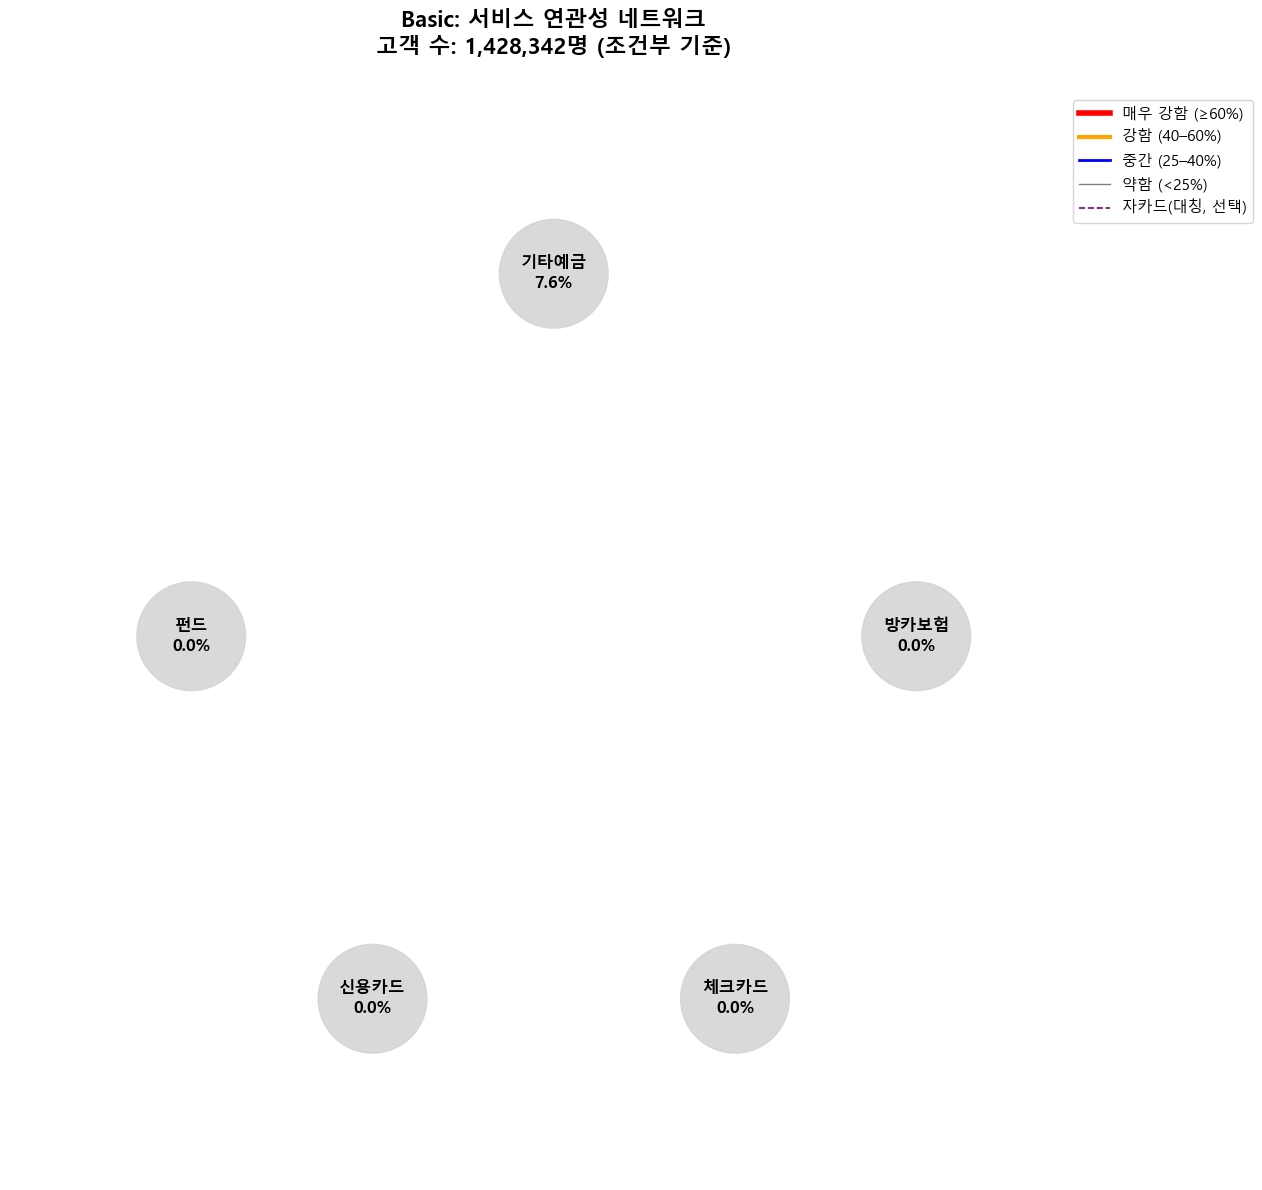

✅ 저장 완료: cluster_network_군집1.png


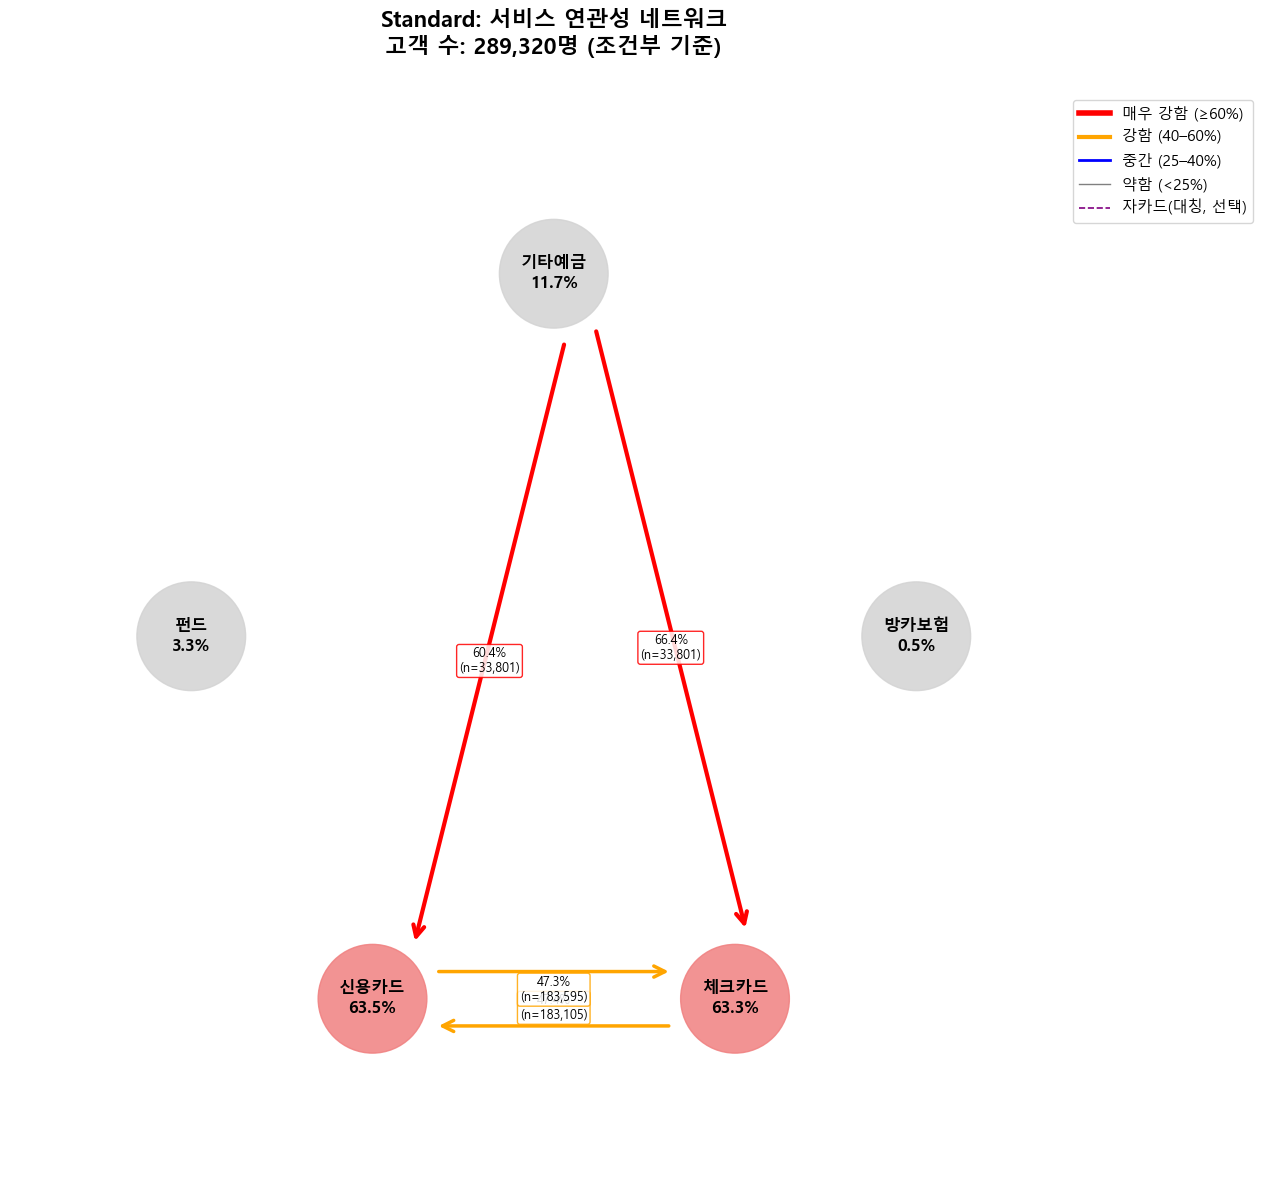

✅ 저장 완료: cluster_network_군집2.png


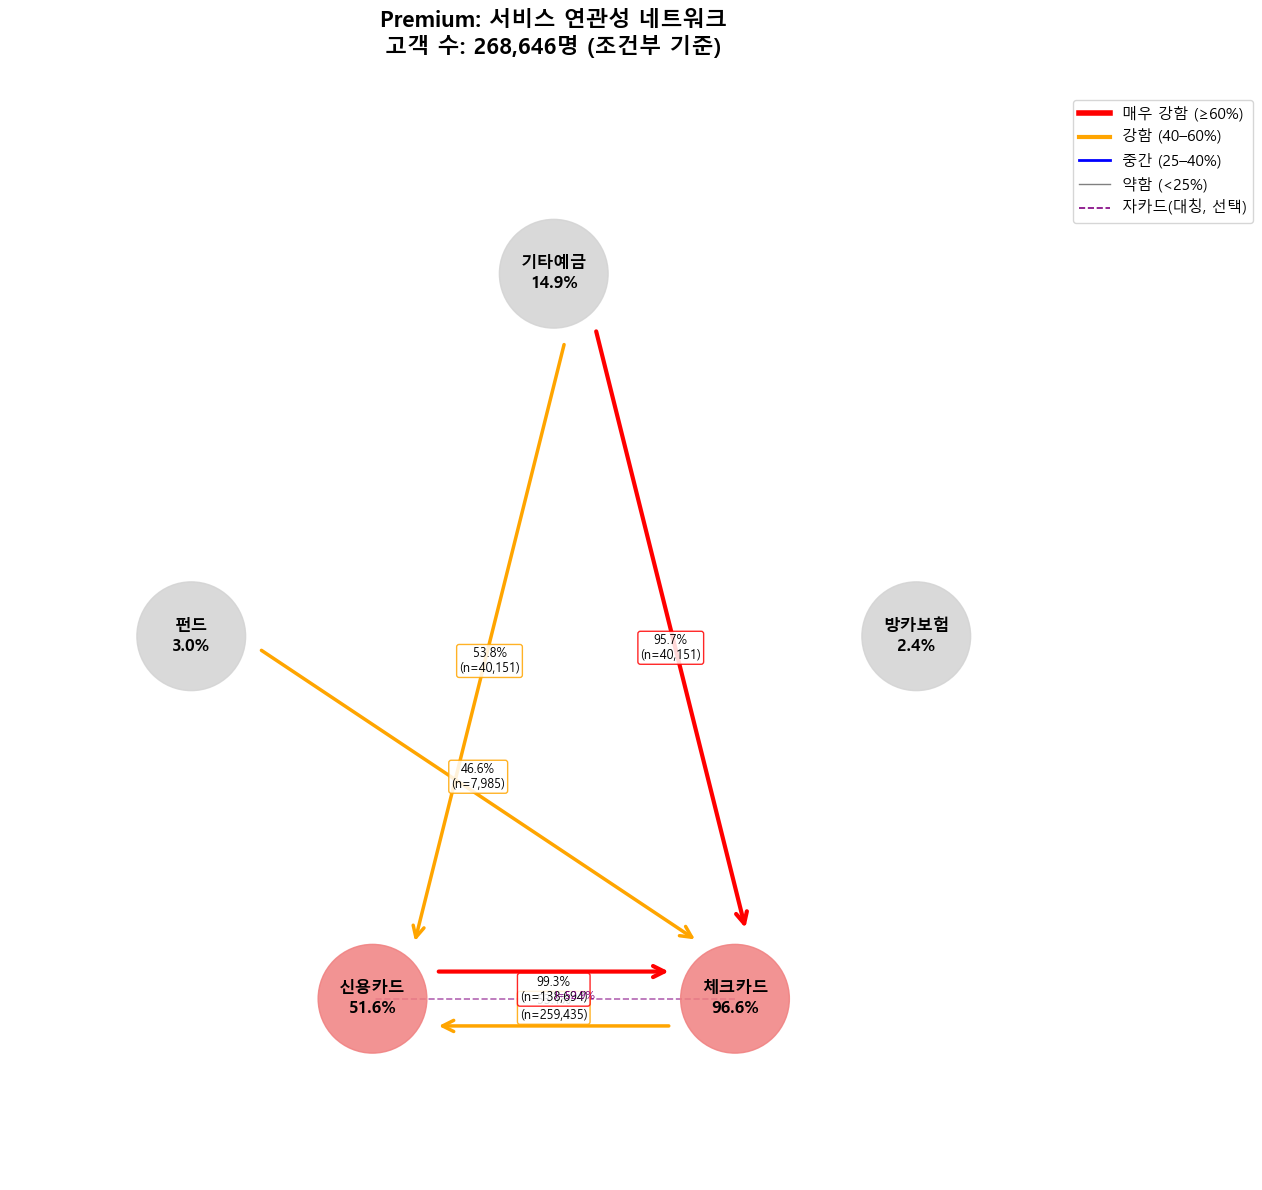

✅ 저장 완료: cluster_network_군집3.png


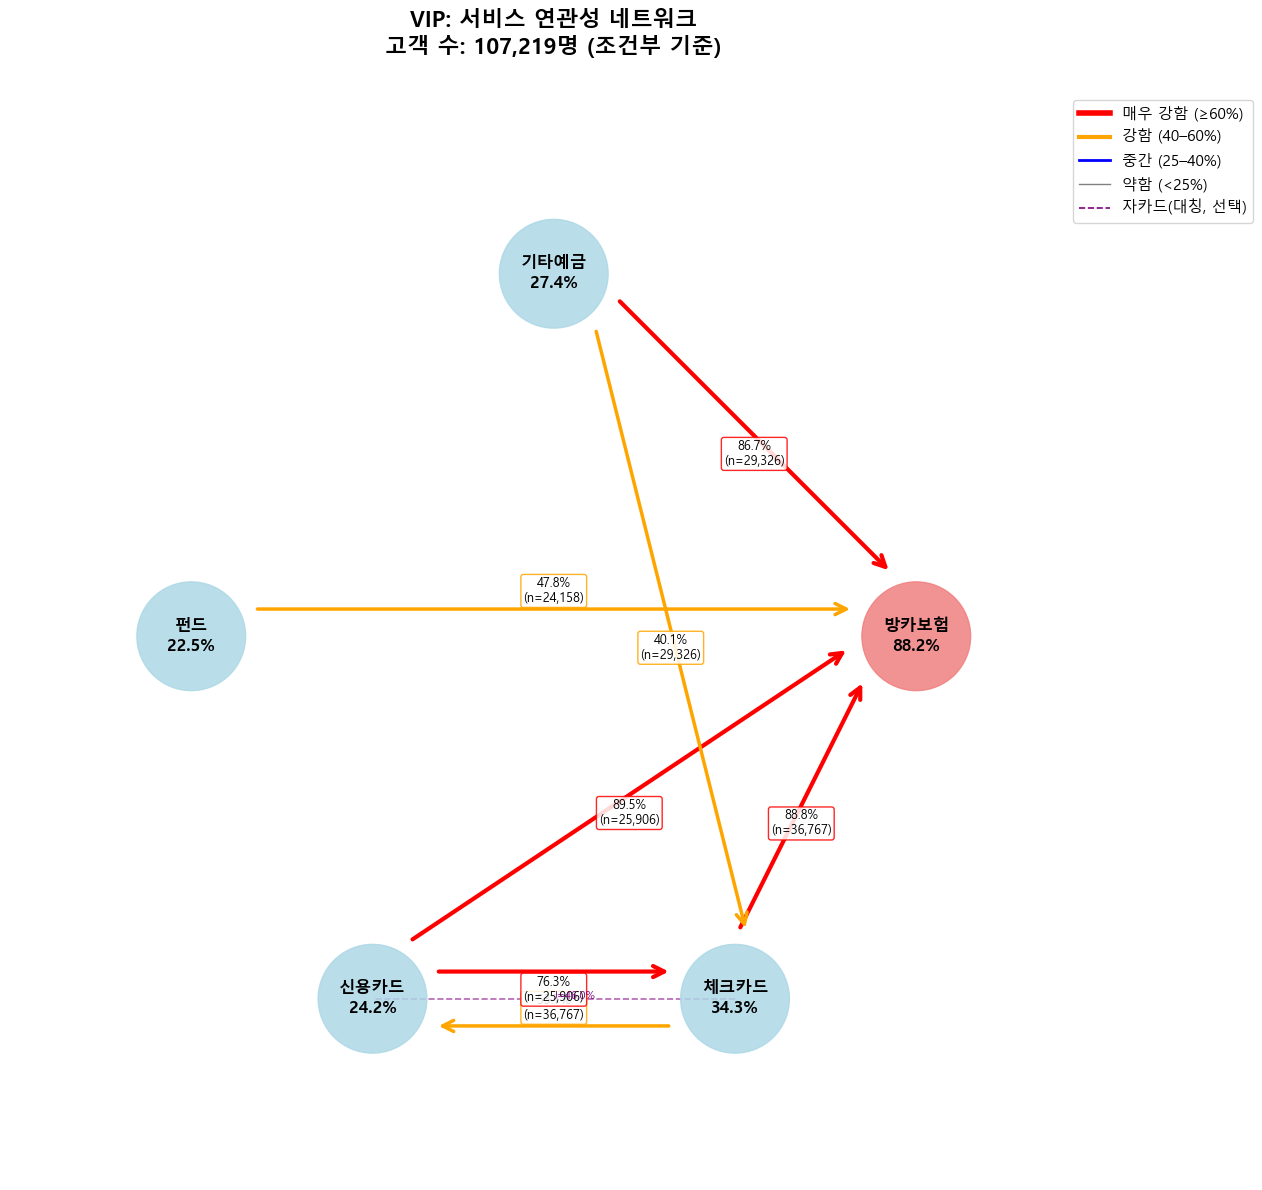

In [30]:
create_cluster_network_avg_save(df)

In [8]:
from matplotlib.patches import FancyArrowPatch


# ─────────────────────────────────────────────────────────
# 0) 설정: 테마, 축약 이름
# ─────────────────────────────────────────────────────────
THEMES = {
    "수신": [
        "입출금식예금평잔", "적립식예금평잔", "거치식예금평잔", "기타예금평잔",
        "펀드잔액", "방카슈랑스잔액"
    ],
    "여신": [
        "원화대출잔액", "주택담보대출", "전세대출", "소액대출", "서민대출", "기업대출잔액"
    ],
    "카드": [
        "신용카드 거래액 합계", "체크카드 거래액 합계", "신용카드 거래횟수", "체크카드 거래횟수"
    ],
    "이체/채널": [
        "자동이체 등록 수", "모바일 이체 횟수", "자동화기기 이용 횟수",
        "모바일뱅킹 등록 여부", "오픈뱅킹 가입 여부", "급여이체 등록 여부"
    ],
}

SHORT = {
    # 수신
    "입출금식예금평잔":"입출금", "적립식예금평잔":"적립식", "거치식예금평잔":"거치식", "기타예금평잔":"기타예금",
    "펀드잔액":"펀드", "방카슈랑스잔액":"방카보험",
    # 여신
    "원화대출잔액":"원대잔", "주택담보대출":"주담대", "전세대출":"전세", "소액대출":"소액", "서민대출":"서민", "기업대출잔액":"기업대",
    # 카드
    "신용카드 거래액 합계":"신카액", "체크카드 거래액 합계":"체카액", "신용카드 거래횟수":"신카횟", "체크카드 거래횟수":"체카횟",
    # 이체/채널
    "자동이체 등록 수":"자동이체", "모바일 이체 횟수":"모바일이체", "자동화기기 이용 횟수":"ATM",
    "모바일뱅킹 등록 여부":"모바일", "오픈뱅킹 가입 여부":"오픈", "급여이체 등록 여부":"급여이체",
}

# ─────────────────────────────────────────────────────────
# 1) 유틸: 사용률(0구간 제외), 연관성 행렬 계산
#    - 연관성: P(B=b | A=a)의 최대값(모든 a,b 중)
#    - exclude_zero_zero=True면 (a=='0구간' and b=='0구간') 셀은 제외
# ─────────────────────────────────────────────────────────
def usage_rate(series):
    # 이분형(y/n)인 경우도 고려
    if series.dropna().isin(["y","n","Y","N","Y ","N "]).all():
        return (series.astype(str).str.lower().eq("y").mean() * 100)
    # 구간형: "0구간" 제외
    return (1 - series.astype(str).eq("0구간").mean()) * 100

def max_conditional_strength(a, b, exclude_zero_zero=True):
    ct = pd.crosstab(a, b, normalize="index") * 100  # 행 기준 정규화 → P(B|A)
    if exclude_zero_zero and ("0구간" in ct.index) and ("0구간" in ct.columns):
        ct = ct.copy()
        ct.loc["0구간","0구간"] = np.nan  # 의미없는 동시 미이용 제거
    return np.nanmax(ct.values) if ct.size else 0.0

# ─────────────────────────────────────────────────────────
# 2) 네트워크 그리기 (하나의 테마에 대해)
# ─────────────────────────────────────────────────────────
def draw_theme_network(
    df_theme, title,
    min_connection_rate=25,
    top_n_services=None,
    exclude_zero_zero=True
):
    cols = list(df_theme.columns)
    if top_n_services:
        # 사용률 상위 N개만 남기기
        rates = {c: usage_rate(df_theme[c]) for c in cols}
        cols = [c for c,_ in sorted(rates.items(), key=lambda x:-x[1])[:top_n_services]]
        df_theme = df_theme[cols]

    if len(cols) < 2:
        print(f"  - 변수 부족으로 스킵 ({len(cols)}개)")
        return

    # 노드 좌표 (원형 배치)
    n = len(cols)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    R = 2.6
    pos = {c: (R*np.cos(a), R*np.sin(a)) for c,a in zip(cols, angles)}

    # 사용률 색
    def node_color(rate):
        if rate >= 70: return "#ef4444"   # 강함
        if rate >= 40: return "#60a5fa"   # 중간
        if rate >= 15: return "#cbd5e1"   # 약함
        return "#e5e7eb"                  # 매우 약함

    # 그림
    plt.figure(figsize=(11, 9))
    ax = plt.gca()

    # 노드 (원 + 라벨)
    for c in cols:
        r = usage_rate(df_theme[c])
        circ = plt.Circle(pos[c], 0.32, color=node_color(r), alpha=0.9, zorder=3)
        ax.add_patch(circ)
        name = SHORT.get(c, c[:6])
        plt.text(pos[c][0], pos[c][1], f"{name}\n{r:.1f}%",
                 ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

    # 엣지 (양방향, 강한 것만)
    drawn = set()
    for i, a_col in enumerate(cols):
        for j, b_col in enumerate(cols):
            if i >= j: 
                continue
            s_ab = max_conditional_strength(df_theme[a_col], df_theme[b_col], exclude_zero_zero)
            s_ba = max_conditional_strength(df_theme[b_col], df_theme[a_col], exclude_zero_zero)
            if (s_ab < min_connection_rate) and (s_ba < min_connection_rate):
                continue

            (x1,y1), (x2,y2) = pos[a_col], pos[b_col]
            dx, dy = x2-x1, y2-y1
            L = np.hypot(dx, dy)
            ux, uy = dx/L, dy/L
            px, py = -uy*0.18, ux*0.18  # 평행 이동(겹침 방지)

            # A→B
            if s_ab >= min_connection_rate:
                start = (x1 + ux*0.40 + px, y1 + uy*0.40 + py)
                end   = (x2 - ux*0.40 + px, y2 - uy*0.40 + py)
                color, lw = ("#ef4444",3) if s_ab>=60 else ("#f59e0b",2.5) if s_ab>=40 else ("#3b82f6",2)
                ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->",
                                             mutation_scale=18, color=color,
                                             linewidth=lw, alpha=0.85, zorder=2))
                mx, my = (start[0]+end[0])/2, (start[1]+end[1])/2
                plt.text(mx, my+0.10, f"{s_ab:.0f}%", fontsize=8, fontweight="bold",
                         ha="center", va="center",
                         bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                                   edgecolor=color, alpha=0.9), zorder=5)

            # B→A
            if s_ba >= min_connection_rate:
                start = (x2 - ux*0.40 - px, y2 - uy*0.40 - py)
                end   = (x1 + ux*0.40 - px, y1 + uy*0.40 - py)
                color, lw = ("#ef4444",3) if s_ba>=60 else ("#f59e0b",2.5) if s_ba>=40 else ("#3b82f6",2)
                ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->",
                                             mutation_scale=18, color=color,
                                             linewidth=lw, alpha=0.85, zorder=2))
                mx, my = (start[0]+end[0])/2, (start[1]+end[1])/2
                plt.text(mx, my-0.10, f"{s_ba:.0f}%", fontsize=8, fontweight="bold",
                         ha="center", va="center",
                         bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                                   edgecolor=color, alpha=0.9), zorder=5)

            drawn.add((a_col,b_col))

    # 축/제목/범례
    plt.axis("equal"); plt.axis("off")
    plt.title(title, fontsize=16, fontweight="bold", pad=20)

    legend_elements = [
        plt.Line2D([0],[0], color="#ef4444", linewidth=3, label="매우 강함 (≥60%)"),
        plt.Line2D([0],[0], color="#f59e0b", linewidth=2.5, label="강함 (40–60%)"),
        plt.Line2D([0],[0], color="#3b82f6", linewidth=2, label="중간 (25–40%)"),
    ]
    plt.legend(handles=legend_elements, loc="upper right", fontsize=10)
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────
# 3) 메인: 군집 × 테마별 네트워크
# ─────────────────────────────────────────────────────────
def thematic_cluster_networks(
    df, cluster_col="비이자수익 군집",
    themes=THEMES,
    min_connection_rate=25,
    top_n_services=None,
    exclude_zero_zero=True
):
    # 테마마다 실제 존재하는 컬럼만 사용
    for cluster in sorted(df[cluster_col].unique()):
        sub = df[df[cluster_col]==cluster].copy()
        print(f"\n{'='*90}\n▶ 군집 {cluster} | 표본수: {len(sub):,}명\n{'='*90}")
        for theme_name, cols in themes.items():
            avail = [c for c in cols if c in sub.columns]
            if not avail:
                print(f"  - [{theme_name}] 사용 가능한 변수 없음 (스킵)")
                continue
            title = f"{theme_name} 네트워크 • 군집 {cluster} (강도≥{min_connection_rate}%, 0-0제외:{exclude_zero_zero})"
            draw_theme_network(
                sub[avail],
                title=title,
                min_connection_rate=min_connection_rate,
                top_n_services=top_n_services,
                exclude_zero_zero=exclude_zero_zero
            )


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ─────────────────────────────────────────────────────────
# 0) 설정: 테마, 축약 이름
# ─────────────────────────────────────────────────────────
THEMES = {
    "수신": [
        "입출금식예금평잔", "적립식예금평잔", "거치식예금평잔", "기타예금평잔",
        "펀드잔액", "방카슈랑스잔액"
    ],
    "여신": [
        "원화대출잔액", "주택담보대출", "전세대출", "소액대출", "서민대출", "기업대출잔액"
    ],
    "카드": [
        "신용카드 거래액 합계", "체크카드 거래액 합계", "신용카드 거래횟수", "체크카드 거래횟수"
    ],
    "이체/채널": [
        "자동이체 등록 수", "모바일 이체 횟수", "자동화기기 이용 횟수",
        "모바일뱅킹 등록 여부", "오픈뱅킹 가입 여부", "급여이체 등록 여부"
    ],
}

SHORT = {
    # 수신
    "입출금식예금평잔":"입출금", "적립식예금평잔":"적립식", "거치식예금평잔":"거치식", "기타예금평잔":"기타예금",
    "펀드잔액":"펀드", "방카슈랑스잔액":"방카보험",
    # 여신
    "원화대출잔액":"원대잔", "주택담보대출":"주담대", "전세대출":"전세", "소액대출":"소액", "서민대출":"서민", "기업대출잔액":"기업대",
    # 카드
    "신용카드 거래액 합계":"신카액", "체크카드 거래액 합계":"체카액", "신용카드 거래횟수":"신카횟", "체크카드 거래횟수":"체카횟",
    # 이체/채널
    "자동이체 등록 수":"자동이체", "모바일 이체 횟수":"모바일이체", "자동화기기 이용 횟수":"ATM",
    "모바일뱅킹 등록 여부":"모바일", "오픈뱅킹 가입 여부":"오픈", "급여이체 등록 여부":"급여이체",
}

# ─────────────────────────────────────────────────────────
# 1) 유틸: 사용여부/사용률, 조건부 강도(평균/최대)
# ─────────────────────────────────────────────────────────
def _is_used(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()
    # y/n형 처리
    if s.dropna().isin(["y","n"]).all():
        return s.eq("y")
    # 구간형 처리: "0구간"이 아닌 경우 사용
    return ~s.eq("0구간")

def usage_rate(series) -> float:
    used = _is_used(series)
    return used.mean() * 100.0

def avg_conditional_strength(a, b, min_support=300):
    """
    평균 조건부 P(B사용 | A사용) [%]와 모수 nA 반환
    """
    A = _is_used(a)
    B = _is_used(b)
    nA = int(A.sum())
    if nA == 0 or nA < min_support:
        return 0.0, nA
    nAB = int((A & B).sum())
    return nAB / nA * 100.0, nA

def max_conditional_strength(a, b, exclude_zero_zero=True):
    """
    (참고용) 구간별 조건부 분포의 최대치 [%]
    """
    ct = pd.crosstab(a, b, normalize="index") * 100  # P(B|A)
    if ct.size == 0:
        return 0.0
    if exclude_zero_zero and ("0구간" in ct.index) and ("0구간" in ct.columns):
        ct = ct.copy()
        ct.loc["0구간","0구간"] = np.nan
    return float(np.nanmax(ct.values))

def conditional_strength(a, b, mode="avg", min_support=300, exclude_zero_zero=True):
    """
    mode="avg": 평균 조건부 (추천)
    mode="max": 최대 셀(탐색용)
    반환: (strength_pct, support_nA)  ※ max 모드일 땐 support_nA=None
    """
    if mode == "avg":
        pct, nA = avg_conditional_strength(a, b, min_support=min_support)
        return pct, nA
    else:
        pct = max_conditional_strength(a, b, exclude_zero_zero=exclude_zero_zero)
        return pct, None

# ─────────────────────────────────────────────────────────
# 2) 네트워크 그리기 (하나의 테마)
# ─────────────────────────────────────────────────────────
def draw_theme_network(
    df_theme, title,
    min_connection_rate=25,
    top_n_services=None,
    mode="avg",               # "avg" or "max"
    min_support=300,
    exclude_zero_zero=True
):
    cols = list(df_theme.columns)
    if top_n_services:
        rates = {c: usage_rate(df_theme[c]) for c in cols}
        cols = [c for c,_ in sorted(rates.items(), key=lambda x:-x[1])[:top_n_services]]
        df_theme = df_theme[cols]

    if len(cols) < 2:
        print(f"  - 변수 부족으로 스킵 ({len(cols)}개)")
        return

    # 원형 배치
    n = len(cols)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    R = 2.6
    pos = {c: (R*np.cos(a), R*np.sin(a)) for c,a in zip(cols, angles)}

    def node_color(rate):
        if rate >= 70: return "#ef4444"   # 강함
        if rate >= 40: return "#60a5fa"   # 중간
        if rate >= 15: return "#cbd5e1"   # 약함
        return "#e5e7eb"                  # 매우 약함

    plt.figure(figsize=(11, 9))
    ax = plt.gca()

    # 노드
    for c in cols:
        r = usage_rate(df_theme[c])
        ax.add_patch(plt.Circle(pos[c], 0.32, color=node_color(r), alpha=0.9, zorder=3))
        name = SHORT.get(c, c[:6])
        plt.text(pos[c][0], pos[c][1], f"{name}\n{r:.1f}%",
                 ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

    # 엣지
    drawn = set()
    for i, a_col in enumerate(cols):
        for j, b_col in enumerate(cols):
            if i >= j: 
                continue

            s_ab, nA = conditional_strength(df_theme[a_col], df_theme[b_col],
                                            mode=mode, min_support=min_support,
                                            exclude_zero_zero=exclude_zero_zero)
            s_ba, nB = conditional_strength(df_theme[b_col], df_theme[a_col],
                                            mode=mode, min_support=min_support,
                                            exclude_zero_zero=exclude_zero_zero)

            if (s_ab < min_connection_rate) and (s_ba < min_connection_rate):
                continue

            (x1,y1), (x2,y2) = pos[a_col], pos[b_col]
            dx, dy = x2-x1, y2-y1
            L = np.hypot(dx, dy)
            ux, uy = dx/L, dy/L
            px, py = -uy*0.18, ux*0.18  # 평행 이동

            def style(pct):
                if pct >= 60: return ("#ef4444", 3)
                if pct >= 40: return ("#f59e0b", 2.5)
                if pct >= 25: return ("#3b82f6", 2)
                return ("#9ca3af", 1.5)

            def alpha_from_support(n):
                if (mode == "max") or (n is None):
                    return 0.85
                # 0.25 ~ 1.0 스케일링
                return max(0.25, min(1.0, n / (min_support * 2)))

            # A→B
            if s_ab >= min_connection_rate:
                color, lw = style(s_ab)
                start = (x1 + ux*0.40 + px, y1 + uy*0.40 + py)
                end   = (x2 - ux*0.40 + px, y2 - uy*0.40 + py)
                ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->",
                                             mutation_scale=18, color=color,
                                             linewidth=lw, alpha=alpha_from_support(nA), zorder=2))
                mx, my = (start[0]+end[0])/2, (start[1]+end[1])/2
                label = f"{s_ab:.1f}%"
                if (mode=="avg") and (nA is not None):
                    label += f"\n(n={nA:,})"
                plt.text(mx, my+0.10, label, fontsize=8, fontweight="bold",
                         ha="center", va="center",
                         bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                                   edgecolor=color, alpha=0.9), zorder=5)

            # B→A
            if s_ba >= min_connection_rate:
                color, lw = style(s_ba)
                start = (x2 - ux*0.40 - px, y2 - uy*0.40 - py)
                end   = (x1 + ux*0.40 - px, y1 + uy*0.40 - py)
                ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->",
                                             mutation_scale=18, color=color,
                                             linewidth=lw, alpha=alpha_from_support(nB), zorder=2))
                mx, my = (start[0]+end[0])/2, (start[1]+end[1])/2
                label = f"{s_ba:.1f}%"
                if (mode=="avg") and (nB is not None):
                    label += f"\n(n={nB:,})"
                plt.text(mx, my-0.10, label, fontsize=8, fontweight="bold",
                         ha="center", va="center",
                         bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                                   edgecolor=color, alpha=0.9), zorder=5)

            drawn.add((a_col,b_col))

    # 축/제목/범례
    plt.axis("equal"); plt.axis("off")
    plt.title(title, fontsize=16, fontweight="bold", pad=20)

    legend_elements = [
        plt.Line2D([0],[0], color="#ef4444", linewidth=3, label="매우 강함 (≥60%)"),
        plt.Line2D([0],[0], color="#f59e0b", linewidth=2.5, label="강함 (40–60%)"),
        plt.Line2D([0],[0], color="#3b82f6", linewidth=2, label="중간 (25–40%)"),
        plt.Line2D([0],[0], color="#9ca3af", linewidth=1.5, label="약함 (15–25%)"),
    ]
    plt.legend(handles=legend_elements, loc="upper right", fontsize=10)
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────
# 3) 메인: 군집 × 테마별 네트워크
# ─────────────────────────────────────────────────────────
def thematic_cluster_networks(
    df, cluster_col="비이자수익 군집",
    themes=THEMES,
    min_connection_rate=25,
    top_n_services=None,
    mode="avg",            # "avg" 권장
    min_support=300,
    exclude_zero_zero=True
):
    for cluster in sorted(df[cluster_col].unique()):
        sub = df[df[cluster_col]==cluster].copy()
        print(f"\n{'='*90}\n▶ 군집 {cluster} | 표본수: {len(sub):,}명\n{'='*90}")
        for theme_name, cols in themes.items():
            avail = [c for c in cols if c in sub.columns]
            if not avail:
                print(f"  - [{theme_name}] 사용 가능한 변수 없음 (스킵)")
                continue
            title = (f"{theme_name} 네트워크 • 군집 {cluster} "
                     f"(강도≥{min_connection_rate}%, 모드:{mode}"
                     + (f", min_support:{min_support}" if mode=='avg' else "")
                     + (f", 0-0제외:{exclude_zero_zero}" if mode=='max' else "")
                     + ")")
            draw_theme_network(
                sub[avail],
                title=title,
                min_connection_rate=min_connection_rate,
                top_n_services=top_n_services,
                mode=mode,
                min_support=min_support,
                exclude_zero_zero=exclude_zero_zero
            )



▶ 군집 0 | 표본수: 1,428,342명


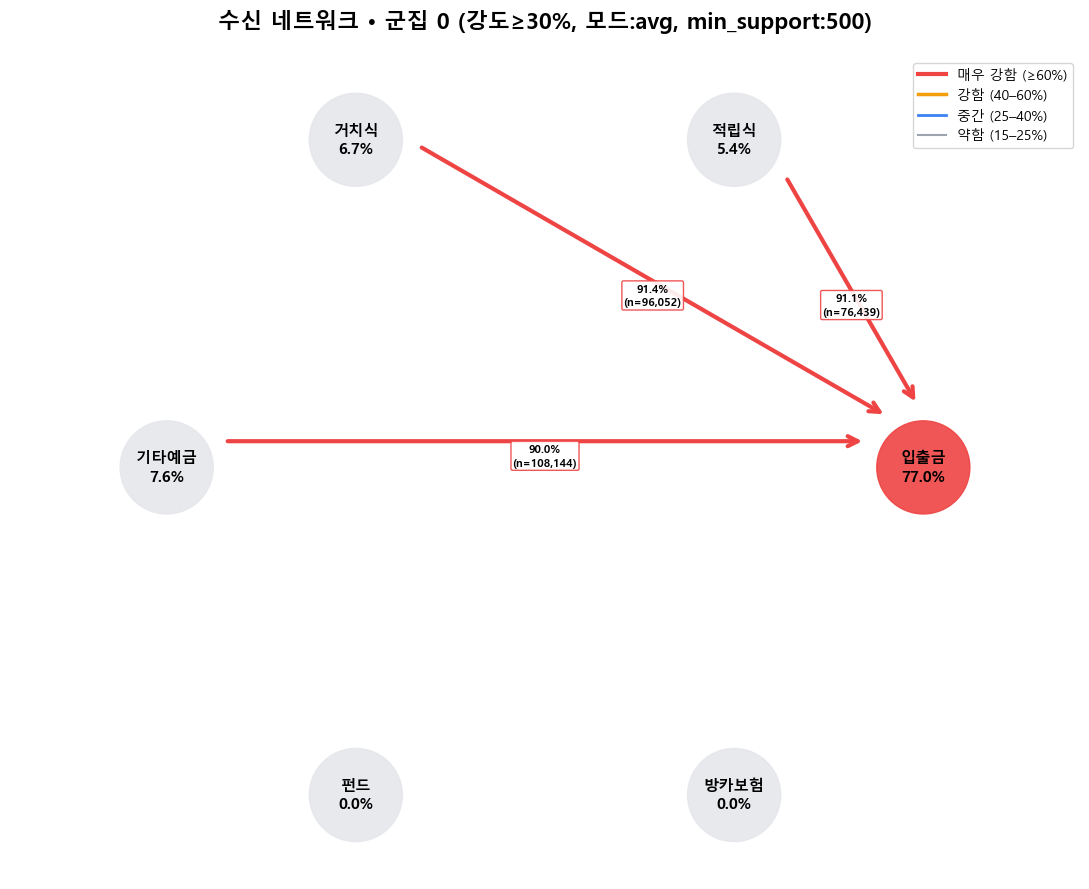

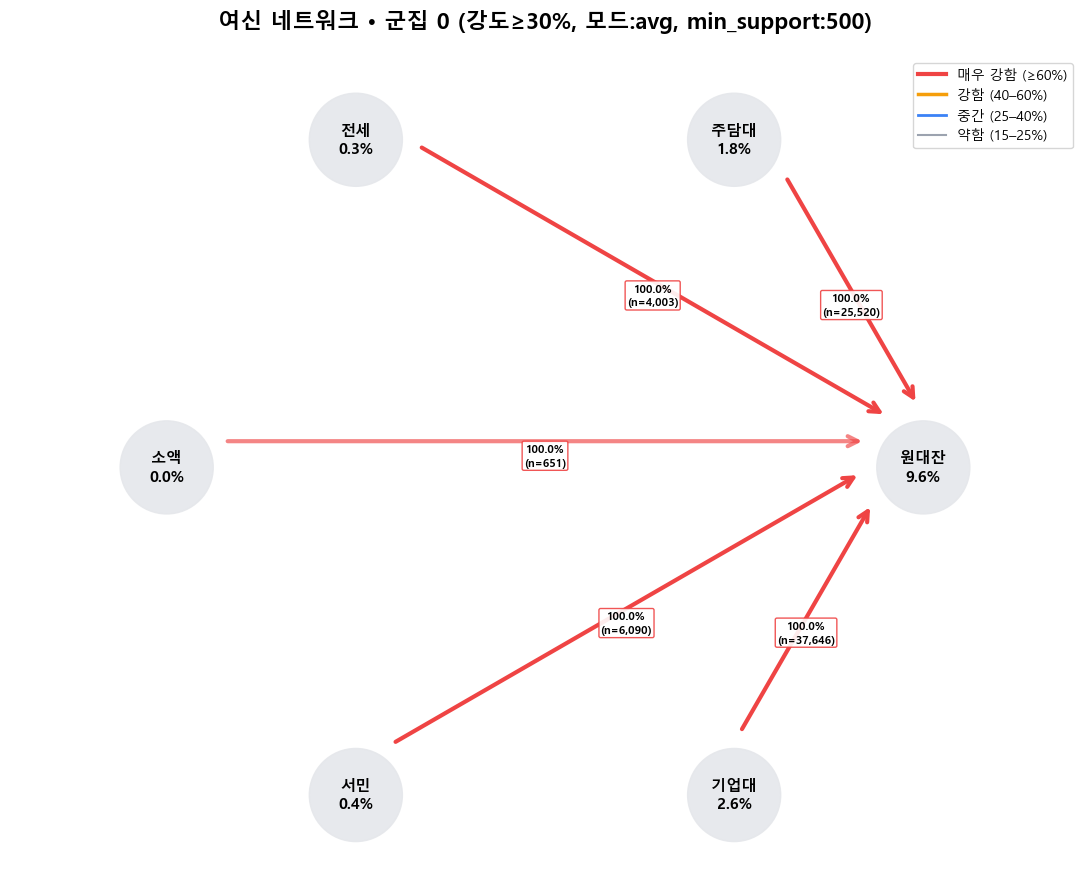

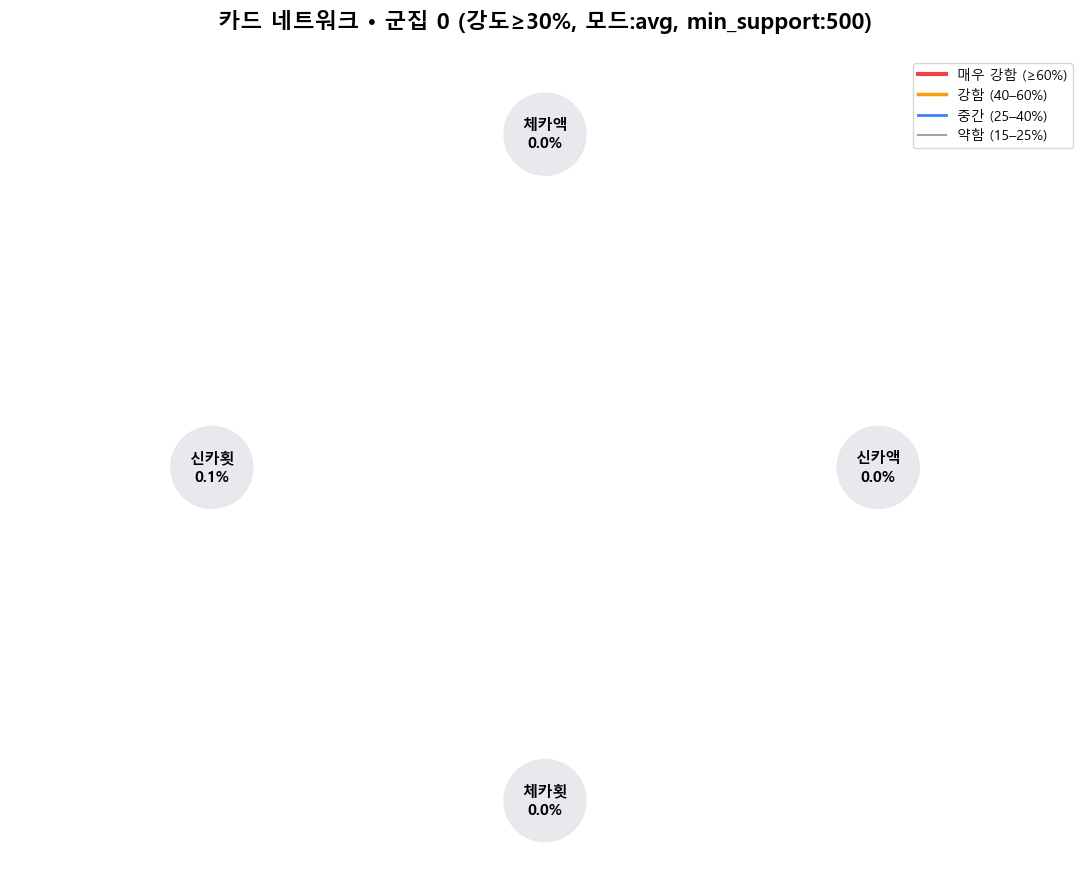

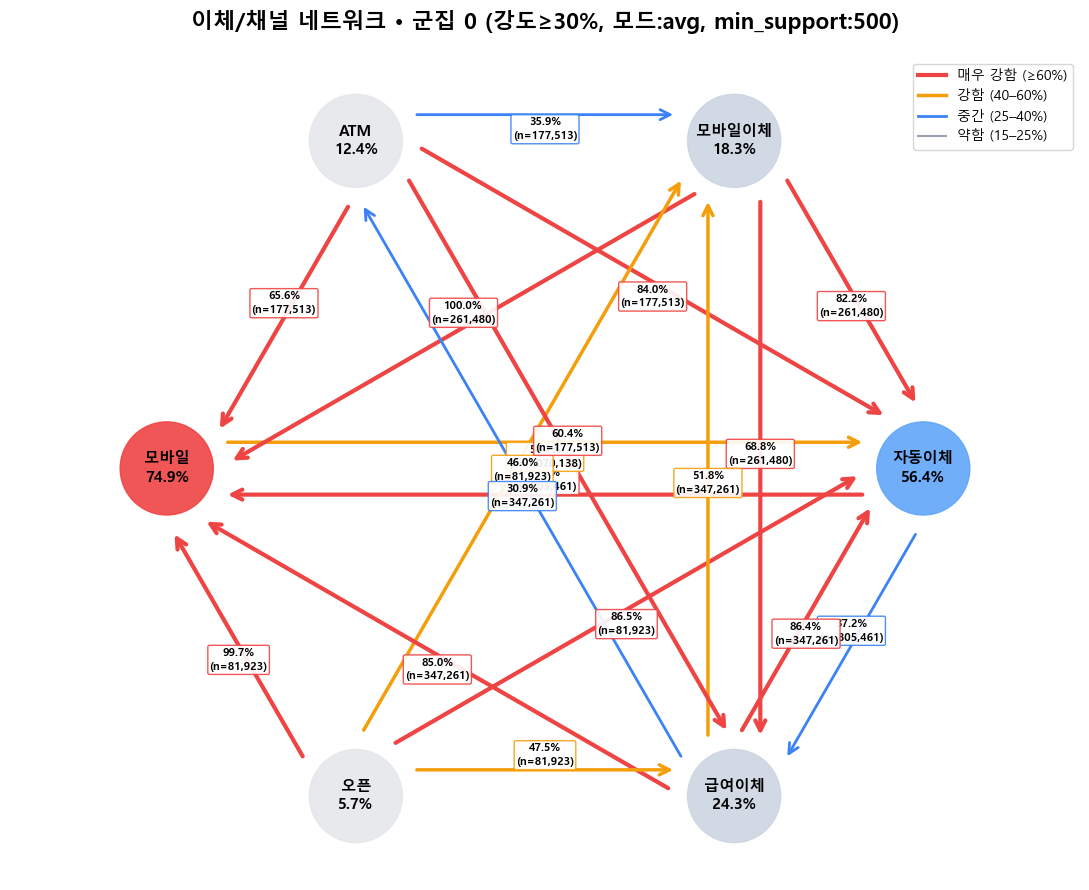


▶ 군집 1 | 표본수: 289,320명


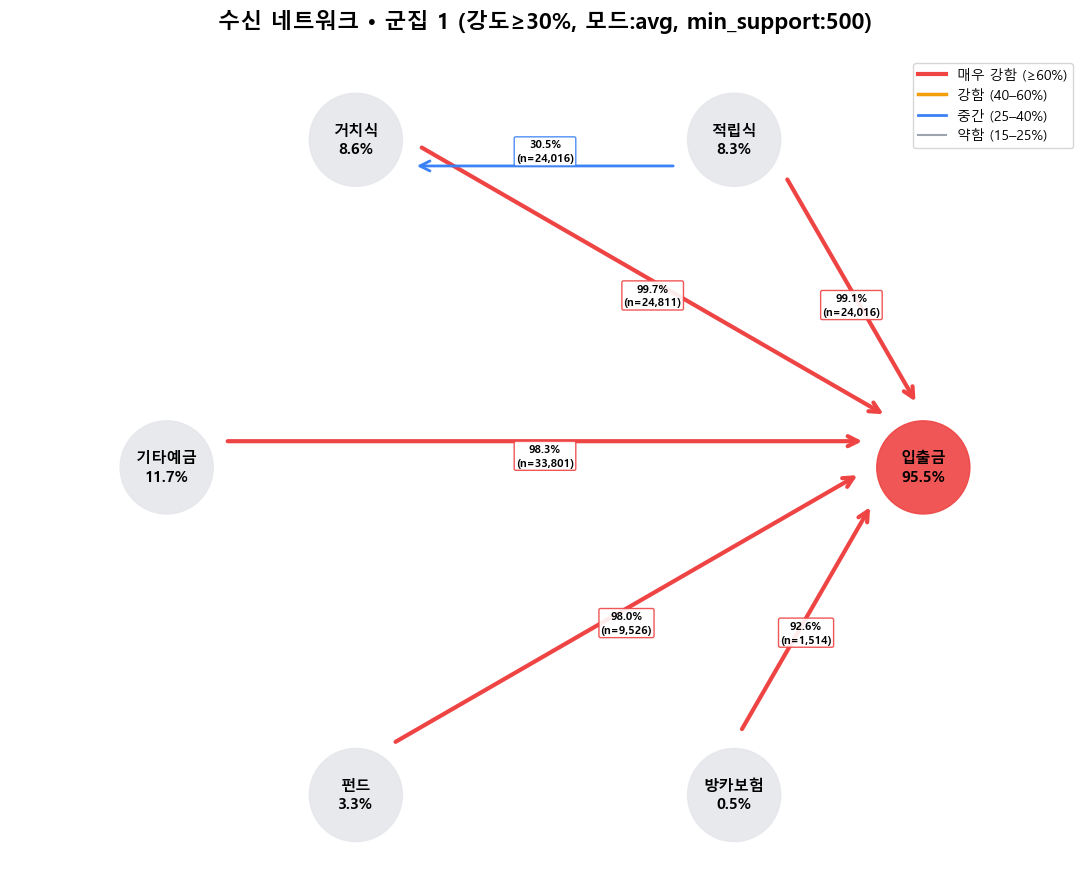

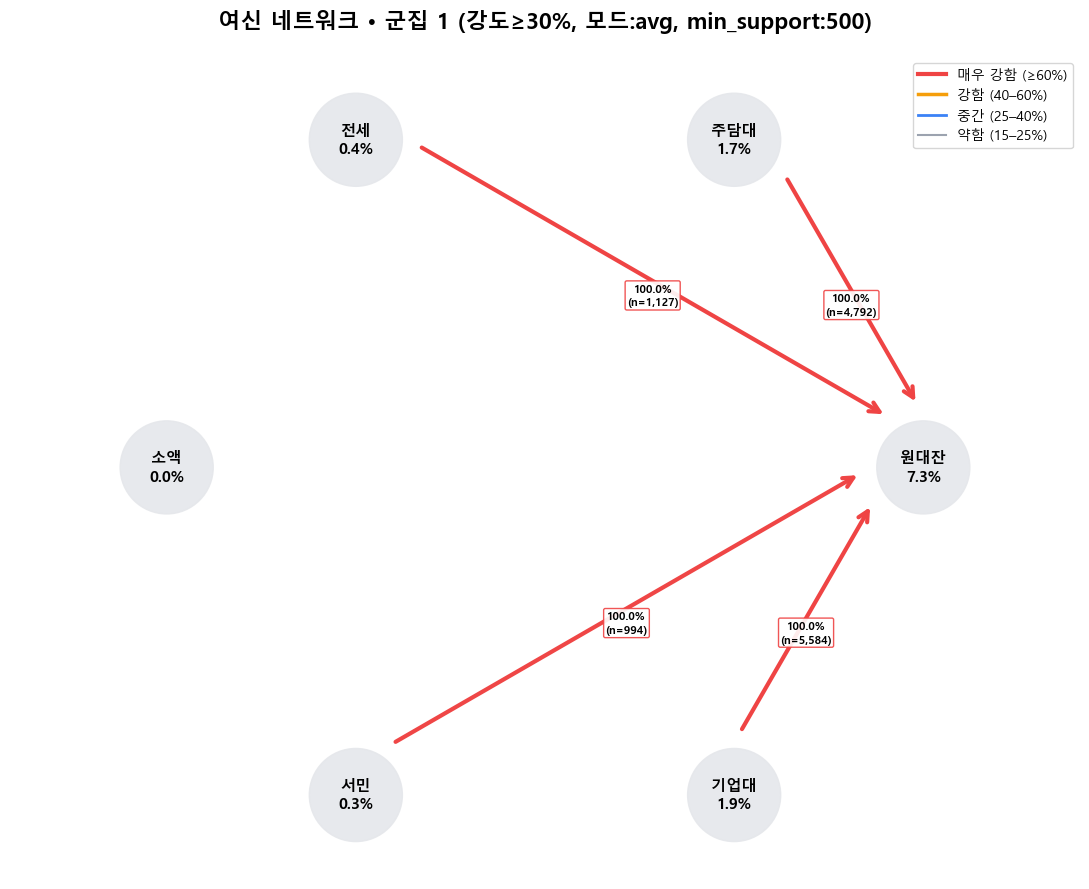

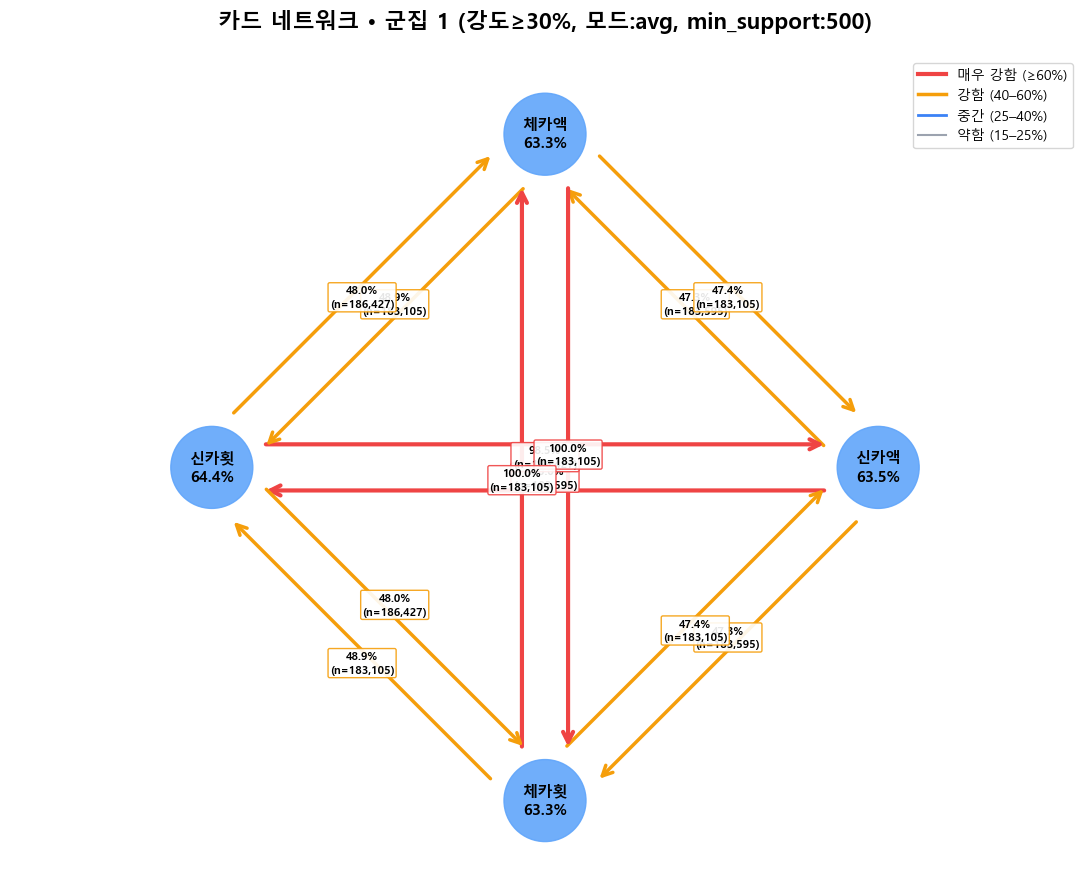

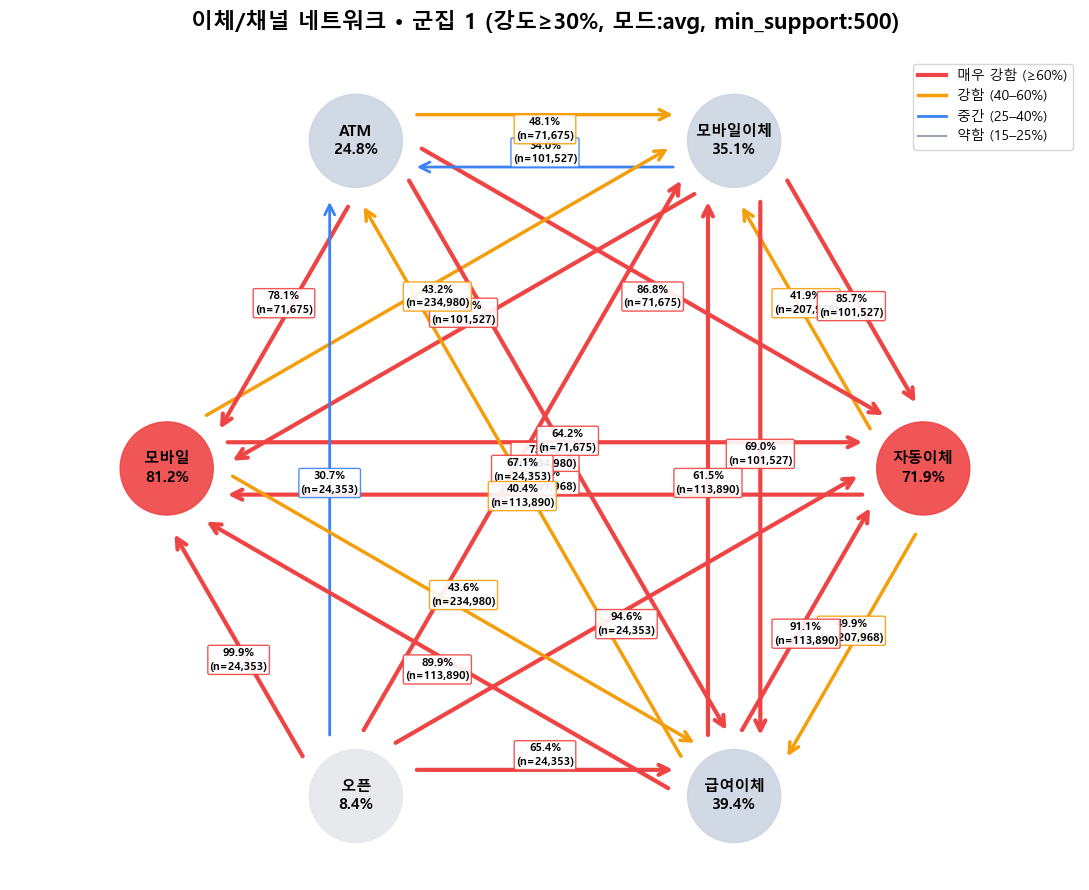


▶ 군집 2 | 표본수: 268,646명


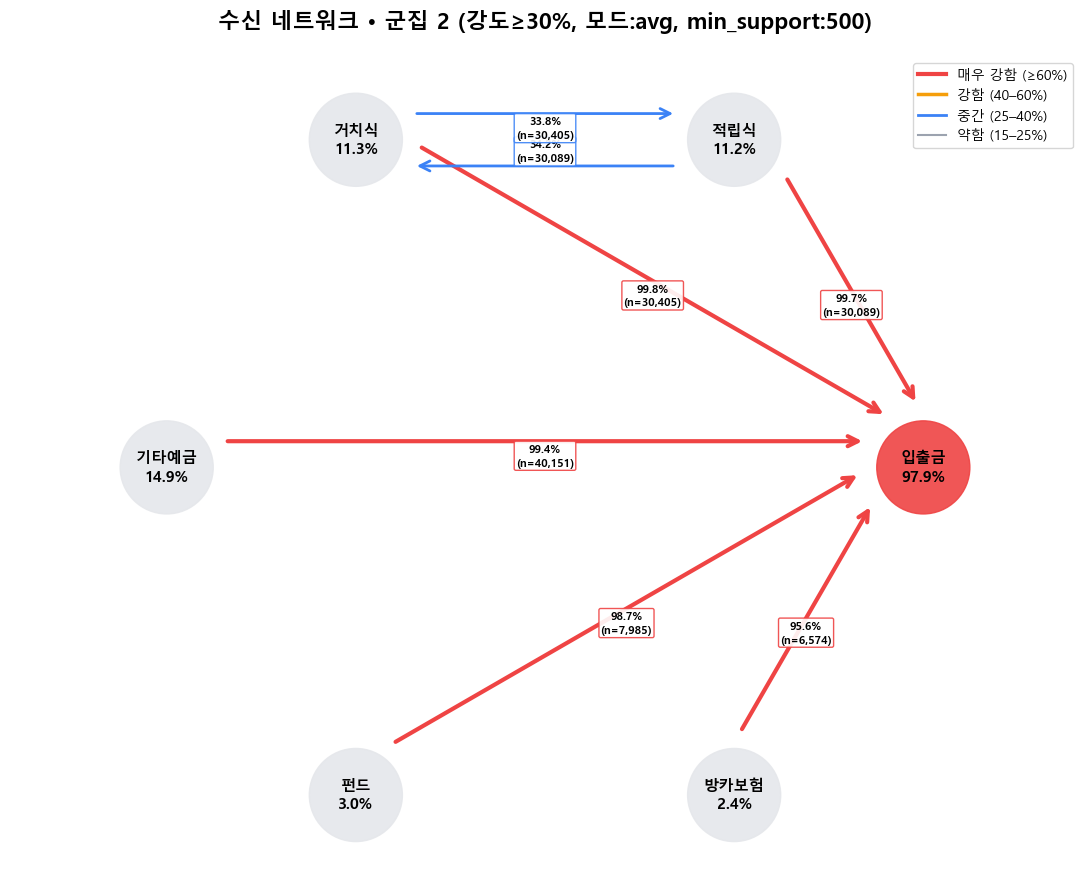

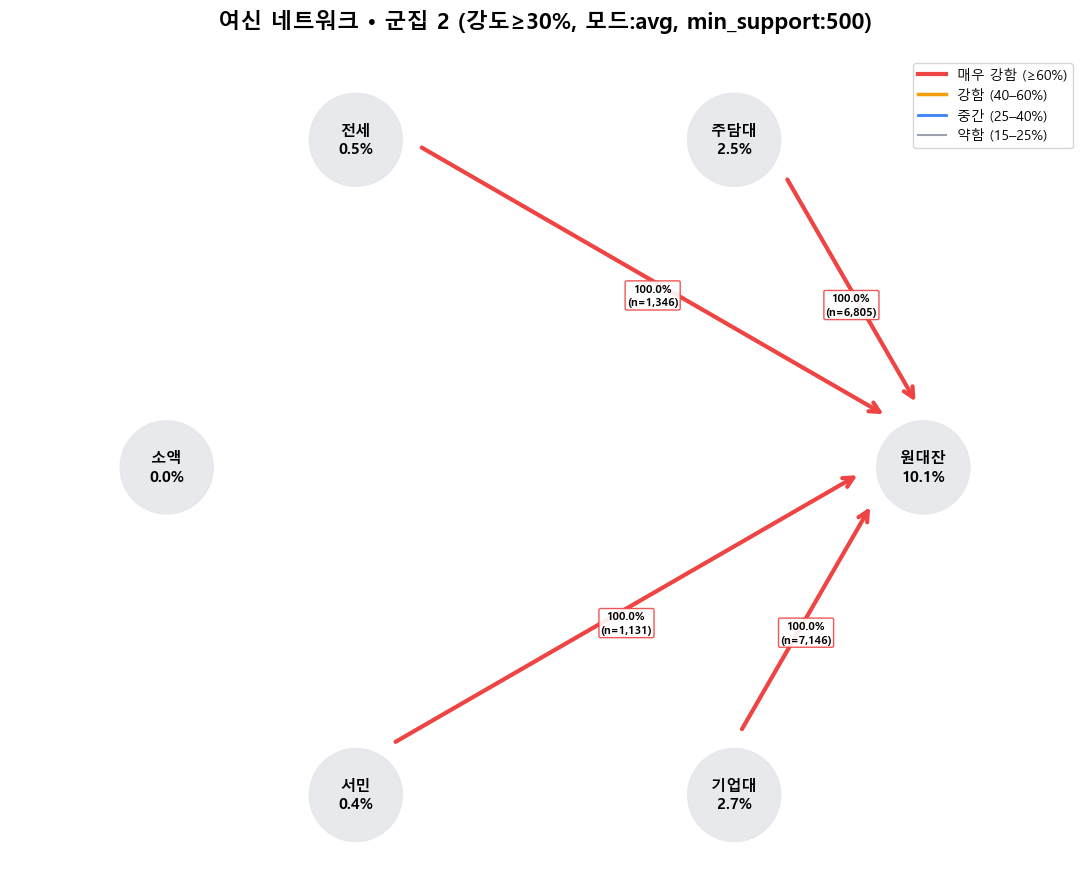

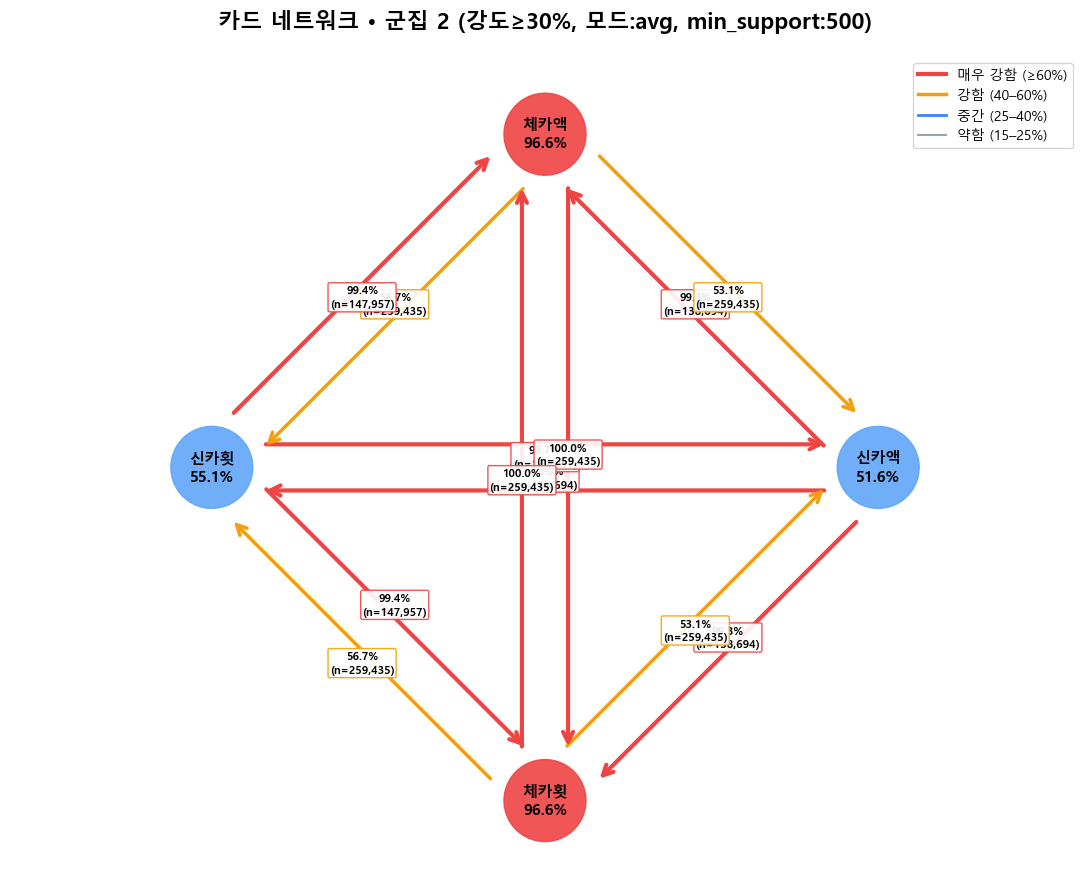

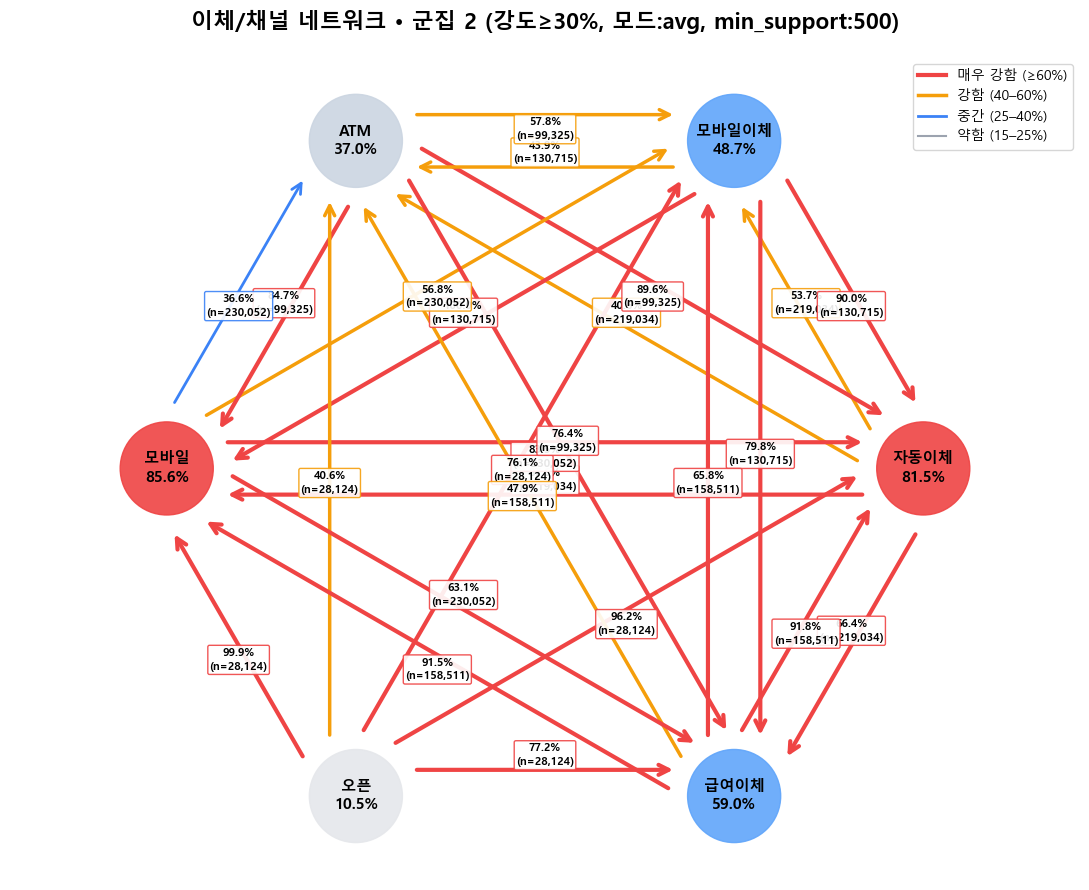


▶ 군집 3 | 표본수: 107,219명


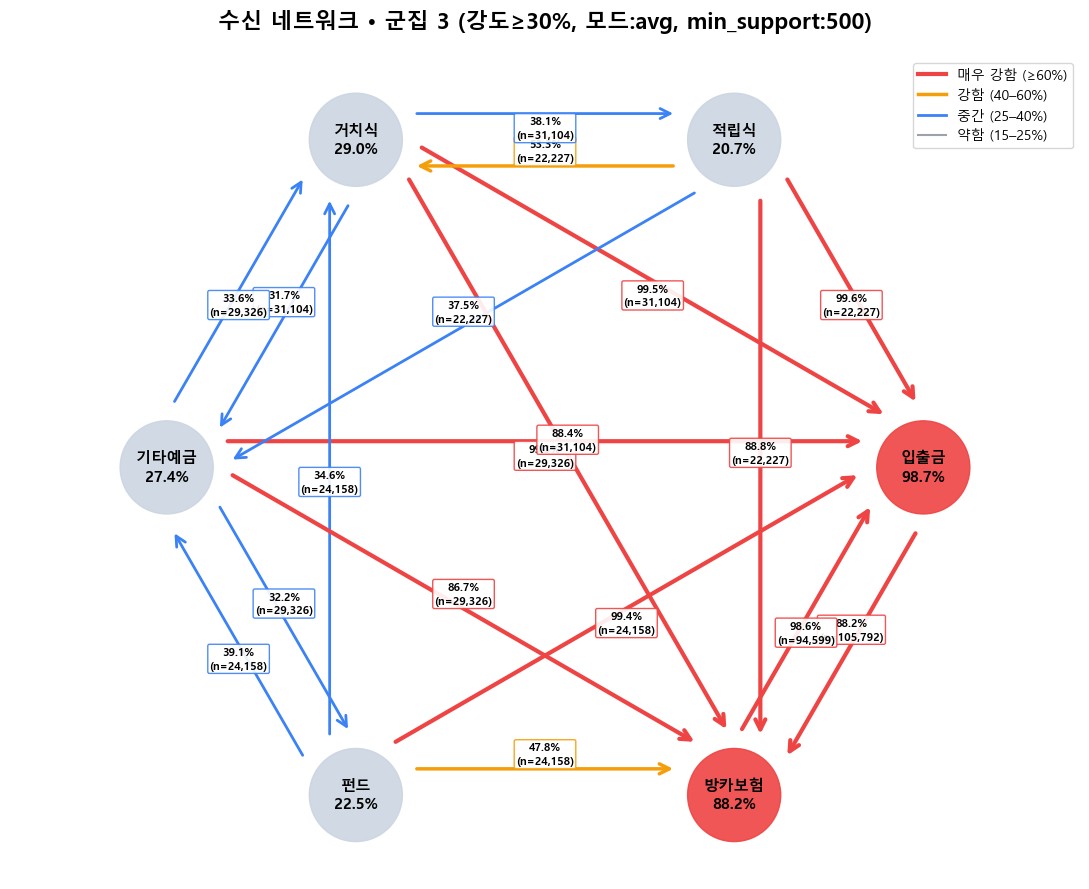

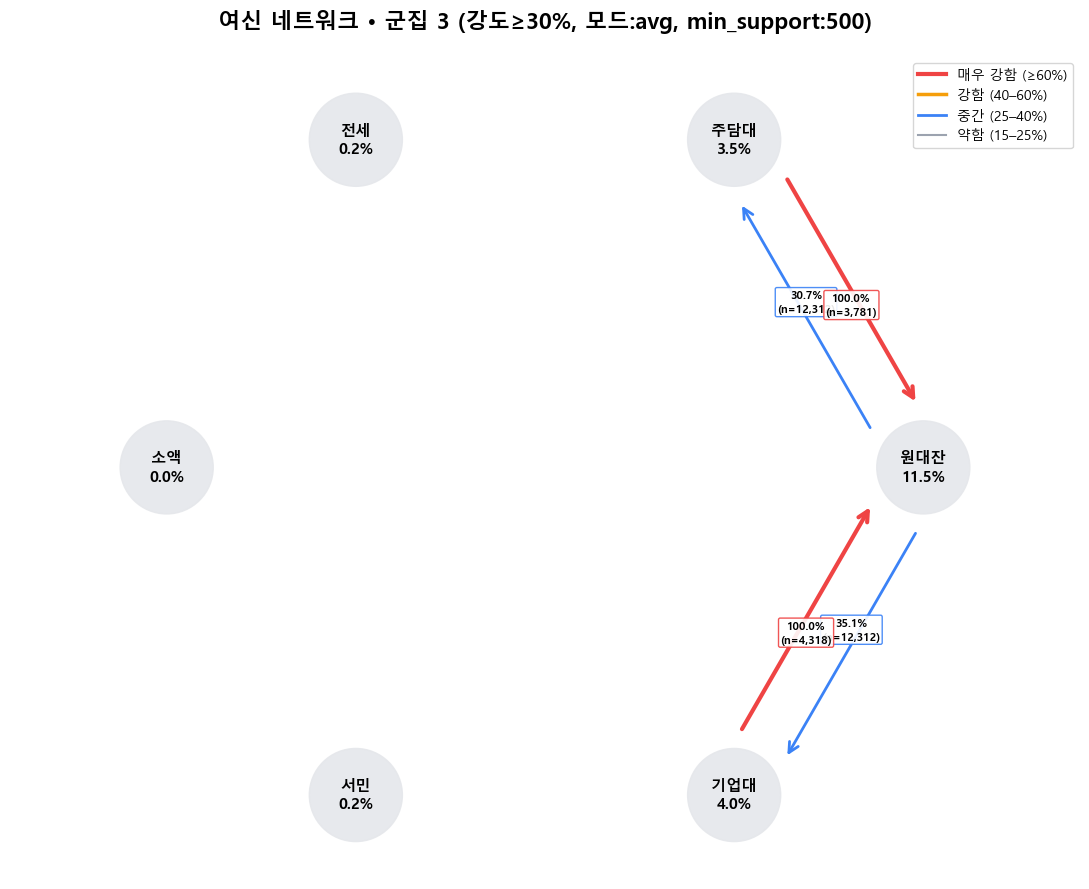

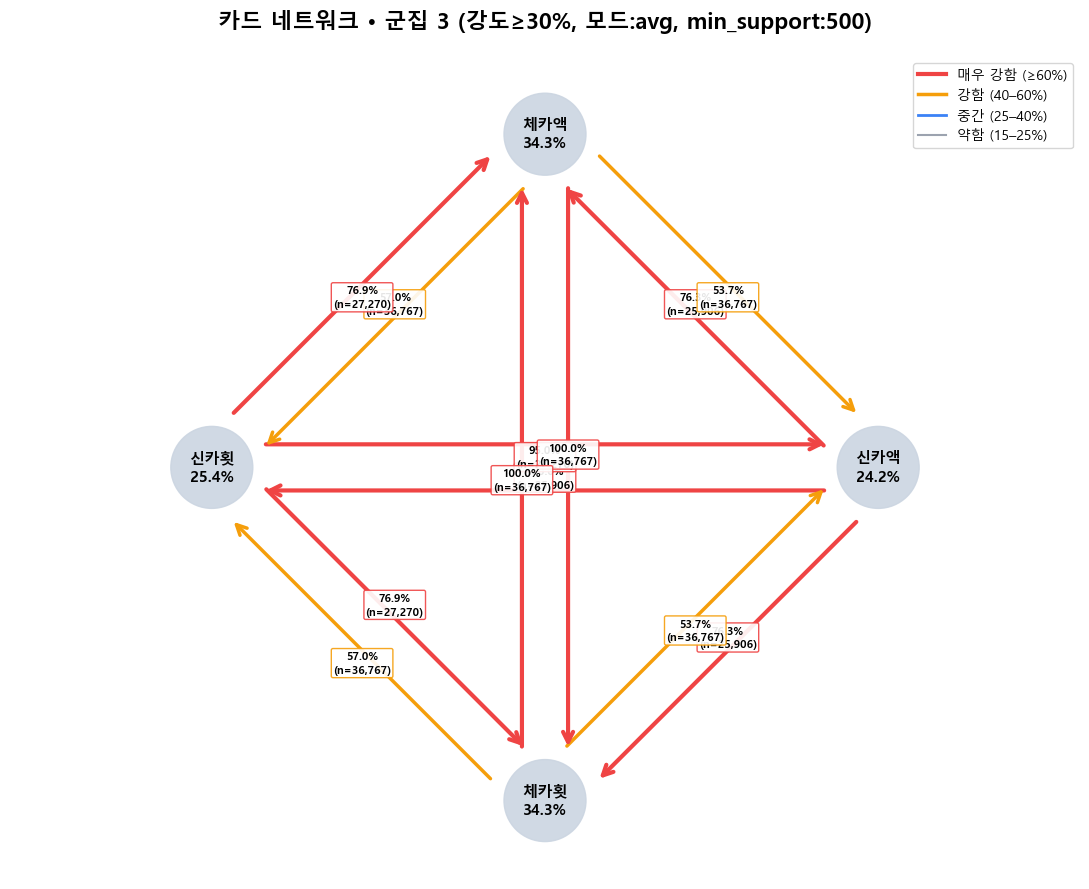

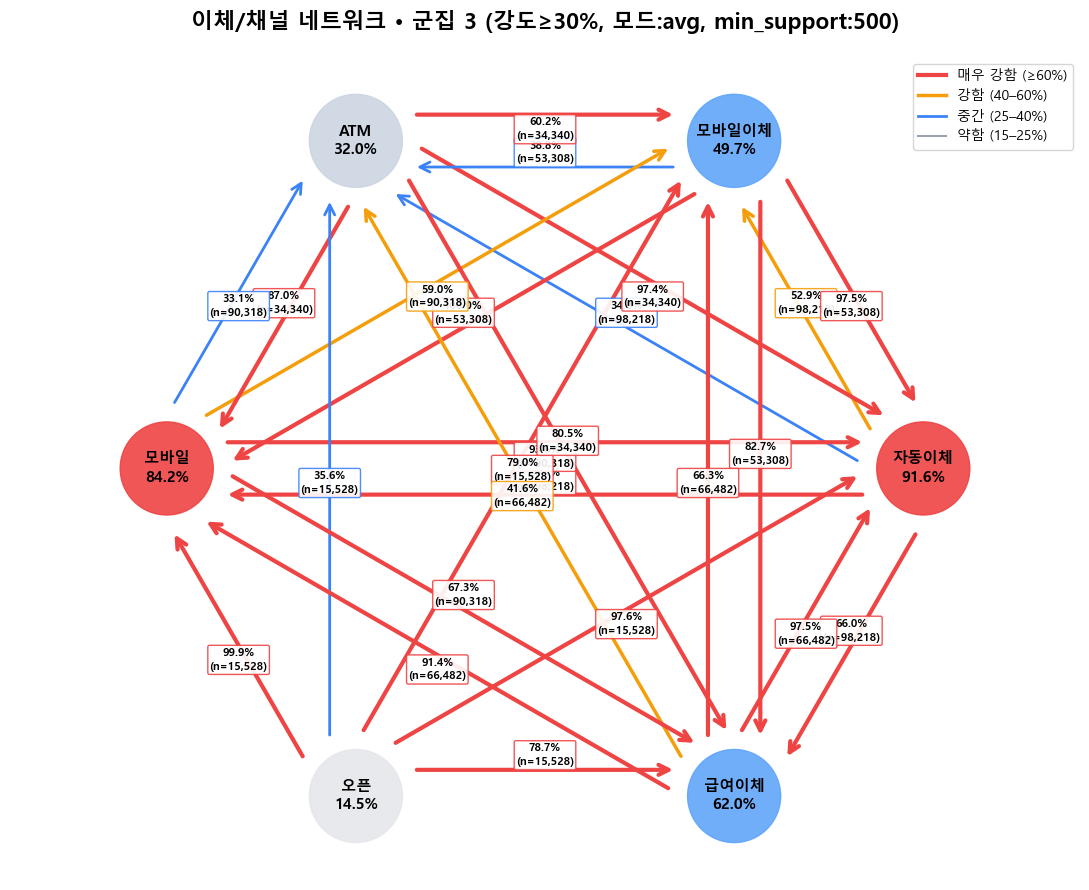

In [10]:
# 평균 조건부(추천), 지원 모수 하한 500, 강도 30% 이상만
thematic_cluster_networks(df, min_connection_rate=30, mode="avg", min_support=500)

# (비교용) 최대치 기반
# thematic_cluster_networks(df, min_connection_rate=60, mode="max", exclude_zero_zero=True)

## (구)고객여정

In [12]:
def customer_journey_cohort_analysis_fixed(df):
    """각 군집 내에서 가입기간별 분포로 고객 여정 패턴 증명"""
    
    # 군집별 가입기간 분포 집계
    cohort_counts = df.groupby(['비이자수익 군집', '가입 기간']).size().reset_index(name='count')
    cluster_totals = df.groupby('비이자수익 군집').size().reset_index(name='cluster_total')
    
    # 군집 내 비율 계산
    cohort_counts = cohort_counts.merge(cluster_totals, on='비이자수익 군집')
    cohort_counts['ratio_within_cluster'] = cohort_counts['count'] / cohort_counts['cluster_total'] * 100
    
    # 피벗 테이블로 변환 (행: 가입기간, 열: 군집)
    cohort_pivot = cohort_counts.pivot(index='가입 기간', columns='비이자수익 군집', values='ratio_within_cluster').fillna(0)
    
    print("=== 각 군집 내 가입기간별 점유율 (%) ===")
    print(cohort_pivot.round(1))
        
    return cohort_pivot

In [13]:
customer_journey_cohort_analysis_fixed(df)

=== 각 군집 내 가입기간별 점유율 (%) ===
비이자수익 군집     0     1     2     3
가입 기간                           
10년 이내     7.4   7.1   6.7   2.7
10년 이상    68.0  80.1  85.5  96.2
3년 이내     17.2   9.8   5.2   0.5
5년 이내      7.4   3.0   2.6   0.6


비이자수익 군집,0,1,2,3
가입 기간,,,,
10년 이내,7.431273,7.112885,6.728930,2.687956
10년 이상,68.040217,80.082953,85.518117,96.185378
3년 이내,17.175928,9.763929,5.179679,0.542814
5년 이내,7.352581,3.040232,2.573275,0.583852


In [14]:
def product_diversity_analysis(df):
    """상품 보유 다양성과 군집 발전의 상관관계 분석"""
    
    # 상품 보유 개수 계산
    product_columns = ['펀드잔액', '방카슈랑스잔액', 
                      '신용카드 거래액 합계', '체크카드 거래액 합계']
    
    for col in product_columns:
        df[f'{col}_보유'] = (df[col] != '0구간').astype(int)
    
    df['상품다양성'] = df[[f'{col}_보유' for col in product_columns]].sum(axis=1)
    
    # 군집별 평균 상품 다양성
    diversity_by_cluster = df.groupby('비이자수익 군집')['상품다양성'].agg(['mean', 'std']).round(2)
    
    print("=== 군집별 상품 다양성 분석 ===")
    print(diversity_by_cluster)
    
    # 상관관계 분석
    correlation = df['비이자수익 군집'].corr(df['상품다양성'])
    print(f"\n군집과 상품다양성 상관계수: {correlation:.3f}")
    
    return diversity_by_cluster

In [15]:
product_diversity_analysis(df)

=== 군집별 상품 다양성 분석 ===
          mean   std
비이자수익 군집            
0         0.00  0.00
1         1.31  0.46
2         1.54  0.52
3         1.69  0.85

군집과 상품다양성 상관계수: 0.852


,mean,std
비이자수익 군집,,
0,0.00,0.00
1,1.31,0.46
2,1.54,0.52
3,1.69,0.85


In [16]:
def dominant_age_group_analysis(df):
    """각 군집별로 가장 높은 비율을 차지하는 연령대와 그 비율 계산"""
    
    print("=== 각 군집별 주력 연령대 분석 ===")
    
    result = {}
    for cluster in sorted(df['비이자수익 군집'].unique()):
        cluster_df = df[df['비이자수익 군집'] == cluster]
        
        # 연령대별 비율 계산
        age_counts = cluster_df['연령대'].value_counts(normalize=True) * 100
        
        # 가장 많은 연령대와 비율
        dominant_age = age_counts.idxmax()
        dominant_ratio = age_counts.max()
        
        # 2위 연령대도 확인
        second_age = age_counts.iloc[1] if len(age_counts) > 1 else 0
        second_age_name = age_counts.index[1] if len(age_counts) > 1 else "없음"
        
        result[cluster] = {
            'dominant_age': dominant_age,
            'dominant_ratio': dominant_ratio,
            'second_age': second_age_name,
            'second_ratio': second_age
        }
        
        print(f"군집 {cluster}: {dominant_age} {dominant_ratio:.1f}% (2위: {second_age_name} {second_age:.1f}%)")
    
    return result

dominant_info = dominant_age_group_analysis(df)

=== 각 군집별 주력 연령대 분석 ===
군집 0: 40대 20.9% (2위: 30대 19.4%)
군집 1: 50대 19.3% (2위: 60대 18.9%)
군집 2: 50대 22.8% (2위: 60대 19.6%)
군집 3: 60대 30.8% (2위: 50대 27.6%)


In [17]:
def digital_adoption_analysis(df):
    """디지털 서비스 활용도와 군집 발전의 관계"""
    
    # 디지털 활용도 점수 계산
    digital_services = ['모바일뱅킹 등록 여부', '오픈뱅킹 가입 여부']
    
    for service in digital_services:
        df[f'{service}_점수'] = (df[service] == 'y').astype(int)
    
    df['디지털활용도'] = df[[f'{service}_점수' for service in digital_services]].sum(axis=1)
    
    # 군집별 디지털 활용도
    digital_by_cluster = df.groupby('비이자수익 군집')['디지털활용도'].mean().round(2)
    
    print("=== 군집별 디지털 활용도 ===")
    for cluster, score in digital_by_cluster.items():
        print(f"군집 {cluster}: {score:.2f}점 (최대 2점)")
    
    # 디지털 활용도별 군집 분포
    digital_cluster = pd.crosstab(df['디지털활용도'], df['비이자수익 군집'], normalize='index') * 100
    
    print("\n=== 디지털 활용도별 군집 분포 (%) ===")
    print(digital_cluster.round(1))
    
    return digital_by_cluster, digital_cluster

In [18]:
digital_adoption_analysis(df)

=== 군집별 디지털 활용도 ===
군집 0: 0.81점 (최대 2점)
군집 1: 0.90점 (최대 2점)
군집 2: 0.96점 (최대 2점)
군집 3: 0.99점 (최대 2점)

=== 디지털 활용도별 군집 분포 (%) ===
비이자수익 군집     0     1     2     3
디지털활용도                          
0         76.5  11.6   8.2   3.6
1         67.0  14.3  13.7   5.1
2         54.6  16.3  18.8  10.4


(비이자수익 군집
 0    0.81
 1    0.90
 2    0.96
 3    0.99
 Name: 디지털활용도, dtype: float64,
 비이자수익 군집          0          1          2          3
 디지털활용도                                              
 0         76.532929  11.611564   8.244465   3.611042
 1         66.976183  14.272369  13.683482   5.067966
 2         54.596614  16.257076  18.775439  10.370870)

In [19]:
def analyze_cluster_differences(df):
    """
    군집별 다양한 특성 차이 분석
    1. 고객등급구분코드 분포
    2. 급여이체 등록 여부
    3. 디지털성숙도 (모바일뱅킹 + 오픈뱅킹)
    4. 모바일뱅킹 가입 여부
    5. 오픈뱅킹 가입 여부
    """
    
    results = {}
    
    print("=" * 60)
    print("         군집별 특성 차이 종합 분석")
    print("=" * 60)
    
    # 1. 군집별 고객등급구분코드 분포
    print("\n📊 1. 군집별 고객등급구분코드 분포(%)")
    print("-" * 40)
    
    customer_grade_dist = df.groupby('비이자수익 군집')['고객등급구분코드'].value_counts(normalize=True).unstack(fill_value=0) * 100
    print(customer_grade_dist.round(1))
    results['고객등급구분코드'] = customer_grade_dist
    
    # 각 군집별 주요 등급 확인
    print("\n📈 군집별 주요 고객등급:")
    for cluster in sorted(df['비이자수익 군집'].unique()):
        top_grade = customer_grade_dist.loc[cluster].idxmax()
        top_ratio = customer_grade_dist.loc[cluster].max()
        print(f"  군집 {cluster}: {top_grade} ({top_ratio:.1f}%)")
    
    # 2. 군집별 급여이체 등록 여부 비율
    print(f"\n📊 2. 군집별 급여이체 등록 여부 비율(%)")
    print("-" * 40)
    
    salary_transfer_rate = df.groupby('비이자수익 군집')['급여이체 등록 여부'].apply(lambda x: (x == 'y').mean() * 100)
    for cluster, rate in salary_transfer_rate.items():
        print(f"  군집 {cluster}: {rate:.1f}%")
    results['급여이체 등록률'] = salary_transfer_rate
    
    # 3. 디지털성숙도 계산 및 분석
    print(f"\n📊 3. 군집별 디지털성숙도 (0~2점)")
    print("-" * 40)
    
    # 디지털성숙도 계산 (모바일뱅킹 + 오픈뱅킹)
    df['모바일뱅킹_점수'] = (df['모바일뱅킹 등록 여부'] == 'y').astype(int)
    df['오픈뱅킹_점수'] = (df['오픈뱅킹 가입 여부'] == 'y').astype(int)
    df['디지털성숙도'] = df['모바일뱅킹_점수'] + df['오픈뱅킹_점수']
    
    digital_maturity = df.groupby('비이자수익 군집')['디지털성숙도'].agg(['mean', 'std']).round(2)
    
    for cluster in sorted(df['비이자수익 군집'].unique()):
        mean_score = digital_maturity.loc[cluster, 'mean']
        std_score = digital_maturity.loc[cluster, 'std']
        print(f"  군집 {cluster}: {mean_score:.2f}점 (±{std_score:.2f})")
    
    results['디지털성숙도'] = digital_maturity
    
    # 디지털성숙도 분포
    print(f"\n📈 디지털성숙도별 분포:")
    digital_dist = df.groupby(['비이자수익 군집', '디지털성숙도']).size().unstack(fill_value=0)
    digital_dist_pct = digital_dist.div(digital_dist.sum(axis=1), axis=0) * 100
    print(digital_dist_pct.round(1))
    
    # 4. 군집별 모바일뱅킹 가입 여부 비율
    print(f"\n📊 4. 군집별 모바일뱅킹 가입률(%)")
    print("-" * 40)
    
    mobile_banking_rate = df.groupby('비이자수익 군집')['모바일뱅킹 등록 여부'].apply(lambda x: (x == 'y').mean() * 100)
    for cluster, rate in mobile_banking_rate.items():
        print(f"  군집 {cluster}: {rate:.1f}%")
    results['모바일뱅킹_가입률'] = mobile_banking_rate
    
    # 5. 군집별 오픈뱅킹 가입 여부 비율
    print(f"\n📊 5. 군집별 오픈뱅킹 가입률(%)")
    print("-" * 40)
    
    open_banking_rate = df.groupby('비이자수익 군집')['오픈뱅킹 가입 여부'].apply(lambda x: (x == 'y').mean() * 100)
    for cluster, rate in open_banking_rate.items():
        print(f"  군집 {cluster}: {rate:.1f}%")
    results['오픈뱅킹_가입률'] = open_banking_rate
    
    # 종합 요약
    print(f"\n" + "=" * 60)
    print("                종합 요약")
    print("=" * 60)
    
    print(f"\n🎯 주요 인사이트:")
    
    # 급여이체 증가 패턴 확인
    salary_trend = "증가" if salary_transfer_rate.iloc[-1] > salary_transfer_rate.iloc[0] else "감소"
    print(f"• 급여이체 등록률: 군집 증가에 따라 {salary_trend} 패턴")
    
    # 디지털성숙도 증가 패턴 확인  
    digital_trend = "증가" if digital_maturity.iloc[-1]['mean'] > digital_maturity.iloc[0]['mean'] else "감소"
    print(f"• 디지털성숙도: 군집 증가에 따라 {digital_trend} 패턴")
    
    # 모바일뱅킹 증가 패턴 확인
    mobile_trend = "증가" if mobile_banking_rate.iloc[-1] > mobile_banking_rate.iloc[0] else "감소"
    print(f"• 모바일뱅킹 가입률: 군집 증가에 따라 {mobile_trend} 패턴")
    
    # 오픈뱅킹 증가 패턴 확인
    open_trend = "증가" if open_banking_rate.iloc[-1] > open_banking_rate.iloc[0] else "감소"
    print(f"• 오픈뱅킹 가입률: 군집 증가에 따라 {open_trend} 패턴")
    
    print(f"\n✅ 결론: 모든 디지털 지표가 군집 레벨과 함께 체계적으로 증가!")
    
    return results

# 실행
results = analyze_cluster_differences(df)

         군집별 특성 차이 종합 분석

📊 1. 군집별 고객등급구분코드 분포(%)
----------------------------------------
고객등급구분코드  0.0   11.0  12.0  13.0
비이자수익 군집                        
0         93.0   1.2   1.9   4.0
1         83.7   0.9   1.6  13.8
2         72.1   1.6   2.8  23.5
3         35.5   8.5  10.2  45.9

📈 군집별 주요 고객등급:
  군집 0: 0.0 (93.0%)
  군집 1: 0.0 (83.7%)
  군집 2: 0.0 (72.1%)
  군집 3: 13.0 (45.9%)

📊 2. 군집별 급여이체 등록 여부 비율(%)
----------------------------------------
  군집 0: 24.3%
  군집 1: 39.4%
  군집 2: 59.0%
  군집 3: 62.0%

📊 3. 군집별 디지털성숙도 (0~2점)
----------------------------------------
  군집 0: 0.81점 (±0.52)
  군집 1: 0.90점 (±0.51)
  군집 2: 0.96점 (±0.50)
  군집 3: 0.99점 (±0.55)

📈 디지털성숙도별 분포:
디지털성숙도       0     1     2
비이자수익 군집                  
0         25.1  69.2   5.7
1         18.8  72.8   8.4
2         14.4  75.2  10.5
3         15.8  69.8  14.5

📊 4. 군집별 모바일뱅킹 가입률(%)
----------------------------------------
  군집 0: 74.9%
  군집 1: 81.2%
  군집 2: 85.6%
  군집 3: 84.2%

📊 5. 군집별 오픈뱅킹 가입률(%)
------------------

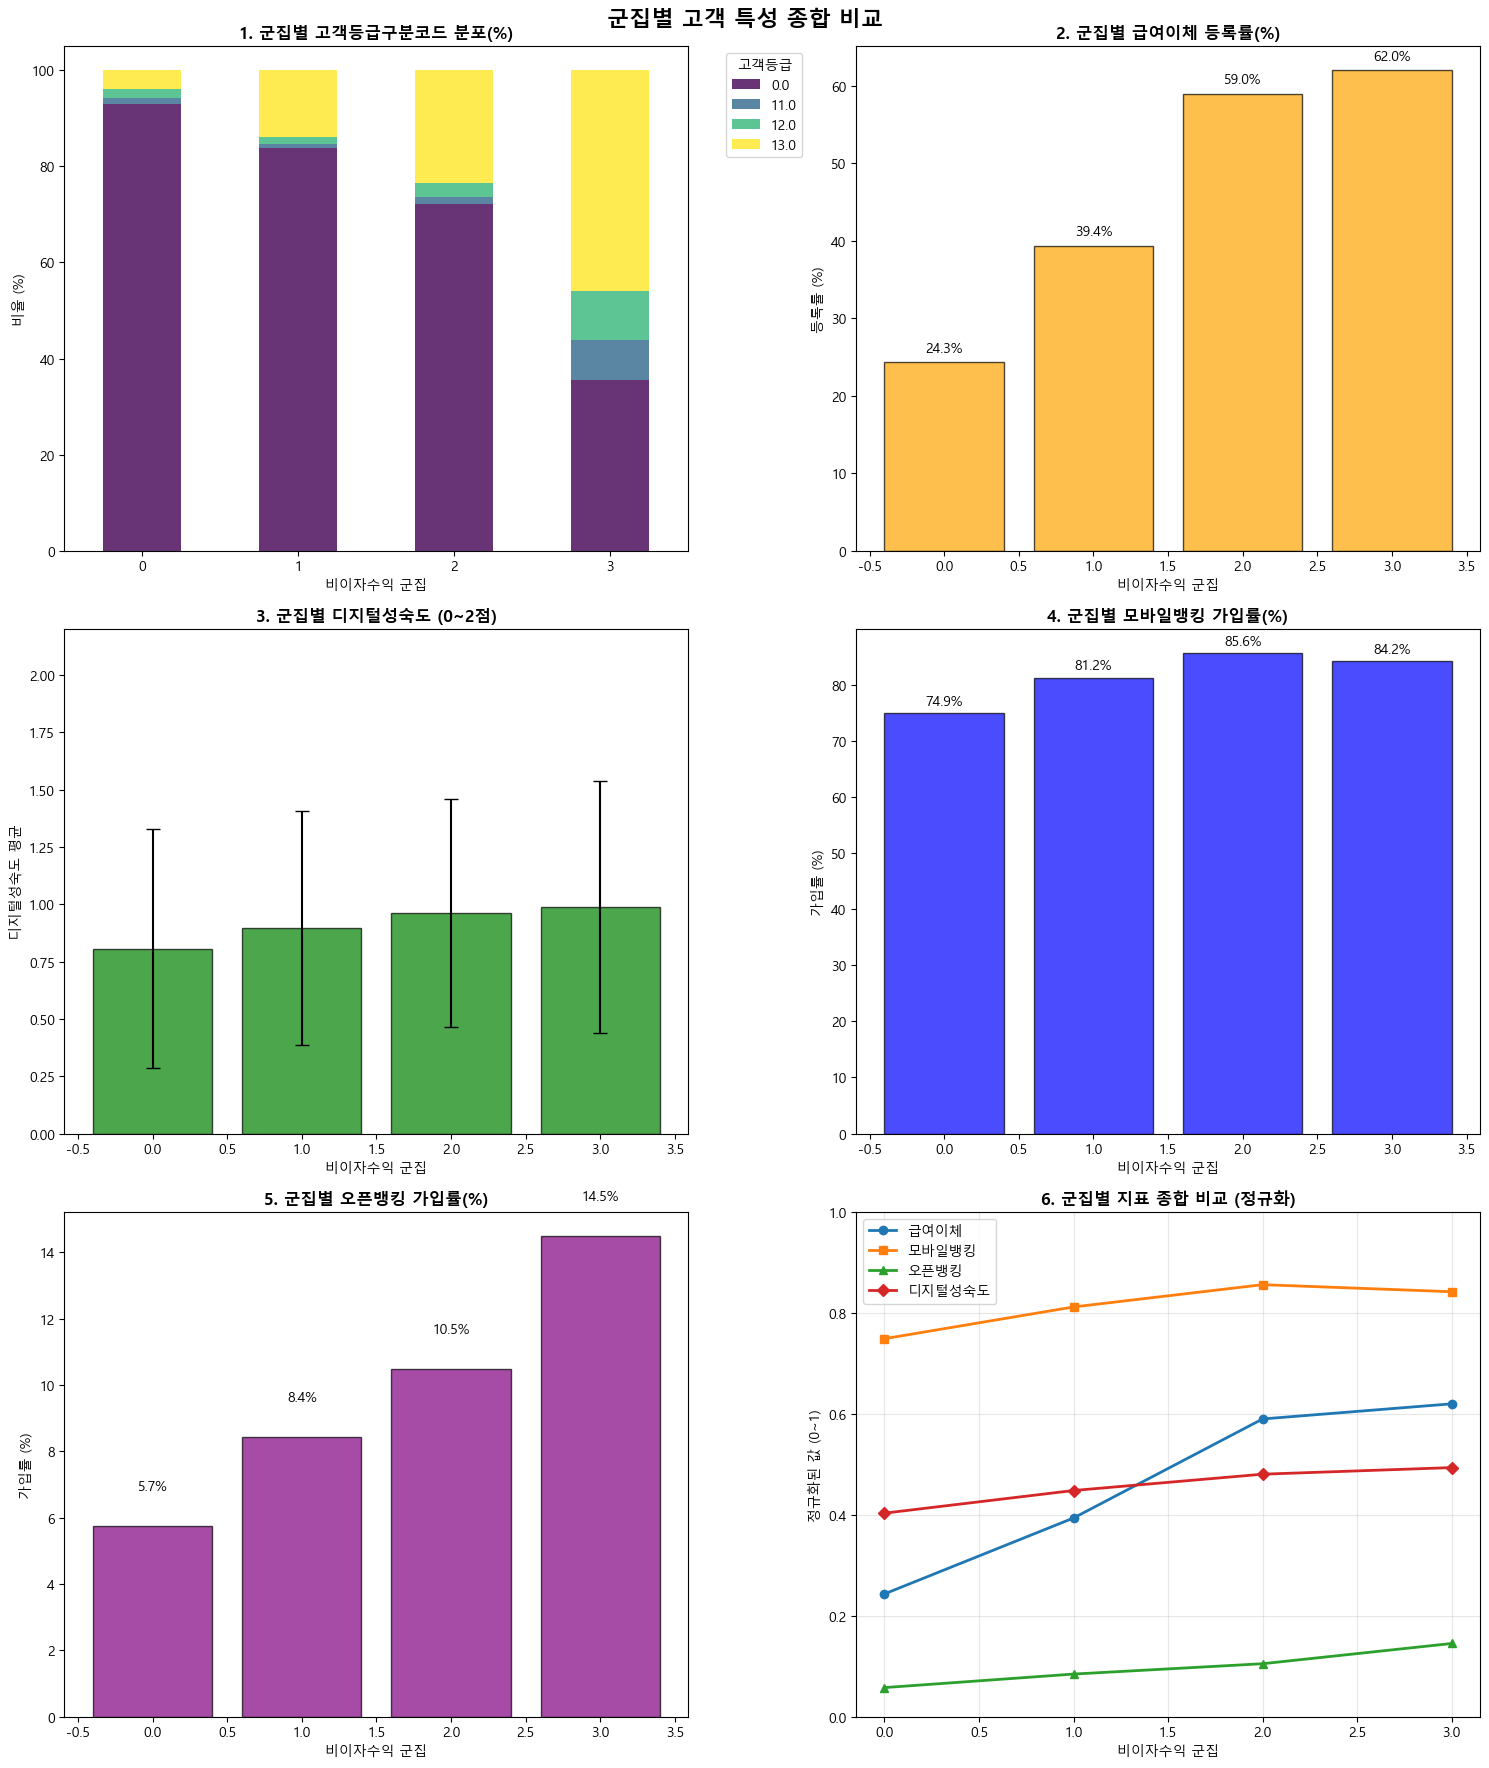

         군집별 특성 차이 수치 요약

📊 군집 0:
  급여이체 등록률: 24.3%
  디지털성숙도: 0.81점
  모바일뱅킹 가입률: 74.9%
  오픈뱅킹 가입률: 5.7%

📊 군집 1:
  급여이체 등록률: 39.4%
  디지털성숙도: 0.90점
  모바일뱅킹 가입률: 81.2%
  오픈뱅킹 가입률: 8.4%

📊 군집 2:
  급여이체 등록률: 59.0%
  디지털성숙도: 0.96점
  모바일뱅킹 가입률: 85.6%
  오픈뱅킹 가입률: 10.5%

📊 군집 3:
  급여이체 등록률: 62.0%
  디지털성숙도: 0.99점
  모바일뱅킹 가입률: 84.2%
  오픈뱅킹 가입률: 14.5%


In [20]:
def analyze_cluster_differences_with_graphs(df):
    """
    군집별 다양한 특성 차이 분석 및 시각화
    1. 고객등급구분코드 분포
    2. 급여이체 등록 여부
    3. 디지털성숙도 (모바일뱅킹 + 오픈뱅킹)
    4. 모바일뱅킹 가입 여부
    5. 오픈뱅킹 가입 여부
    """
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 디지털성숙도 계산
    df['모바일뱅킹_점수'] = (df['모바일뱅킹 등록 여부'] == 'y').astype(int)
    df['오픈뱅킹_점수'] = (df['오픈뱅킹 가입 여부'] == 'y').astype(int)
    df['디지털성숙도'] = df['모바일뱅킹_점수'] + df['오픈뱅킹_점수']
    
    # 데이터 집계
    customer_grade_dist = df.groupby('비이자수익 군집')['고객등급구분코드'].value_counts(normalize=True).unstack(fill_value=0) * 100
    salary_transfer_rate = df.groupby('비이자수익 군집')['급여이체 등록 여부'].apply(lambda x: (x == 'y').mean() * 100)
    digital_maturity = df.groupby('비이자수익 군집')['디지털성숙도'].agg(['mean', 'std'])
    mobile_banking_rate = df.groupby('비이자수익 군집')['모바일뱅킹 등록 여부'].apply(lambda x: (x == 'y').mean() * 100)
    open_banking_rate = df.groupby('비이자수익 군집')['오픈뱅킹 가입 여부'].apply(lambda x: (x == 'y').mean() * 100)
    
    # 그래프 생성
    fig, axes = plt.subplots(3, 2, figsize=(15, 18))
    fig.suptitle('군집별 고객 특성 종합 비교', fontsize=16, fontweight='bold')
    
    # 1. 고객등급구분코드 분포 (적층 막대그래프)
    ax1 = axes[0, 0]
    customer_grade_dist.plot(kind='bar', stacked=True, ax=ax1, 
                           colormap='viridis', alpha=0.8)
    ax1.set_title('1. 군집별 고객등급구분코드 분포(%)', fontweight='bold')
    ax1.set_xlabel('비이자수익 군집')
    ax1.set_ylabel('비율 (%)')
    ax1.legend(title='고객등급', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.tick_params(axis='x', rotation=0)
    
    # 2. 급여이체 등록률
    ax2 = axes[0, 1]
    bars2 = ax2.bar(salary_transfer_rate.index, salary_transfer_rate.values, 
                    color='orange', alpha=0.7, edgecolor='black')
    ax2.set_title('2. 군집별 급여이체 등록률(%)', fontweight='bold')
    ax2.set_xlabel('비이자수익 군집')
    ax2.set_ylabel('등록률 (%)')
    
    # 막대 위에 수치 표시
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 3. 디지털성숙도 (평균 + 표준편차)
    ax3 = axes[1, 0]
    ax3.bar(digital_maturity.index, digital_maturity['mean'], 
            yerr=digital_maturity['std'], capsize=5, 
            color='green', alpha=0.7, edgecolor='black')
    ax3.set_title('3. 군집별 디지털성숙도 (0~2점)', fontweight='bold')
    ax3.set_xlabel('비이자수익 군집')
    ax3.set_ylabel('디지털성숙도 평균')
    ax3.set_ylim(0, 2.2)
    
    # 4. 모바일뱅킹 가입률
    ax4 = axes[1, 1]
    bars4 = ax4.bar(mobile_banking_rate.index, mobile_banking_rate.values, 
                    color='blue', alpha=0.7, edgecolor='black')
    ax4.set_title('4. 군집별 모바일뱅킹 가입률(%)', fontweight='bold')
    ax4.set_xlabel('비이자수익 군집')
    ax4.set_ylabel('가입률 (%)')
    
    # 막대 위에 수치 표시
    for bar in bars4:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 5. 오픈뱅킹 가입률
    ax5 = axes[2, 0]
    bars5 = ax5.bar(open_banking_rate.index, open_banking_rate.values, 
                    color='purple', alpha=0.7, edgecolor='black')
    ax5.set_title('5. 군집별 오픈뱅킹 가입률(%)', fontweight='bold')
    ax5.set_xlabel('비이자수익 군집')
    ax5.set_ylabel('가입률 (%)')
    
    # 막대 위에 수치 표시
    for bar in bars5:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 6. 종합 비교 (라인 차트)
    ax6 = axes[2, 1]
    clusters = salary_transfer_rate.index
    
    # 정규화된 값들로 라인 차트 생성
    salary_norm = salary_transfer_rate / 100
    mobile_norm = mobile_banking_rate / 100
    open_norm = open_banking_rate / 100
    digital_norm = digital_maturity['mean'] / 2
    
    ax6.plot(clusters, salary_norm, marker='o', label='급여이체', linewidth=2)
    ax6.plot(clusters, mobile_norm, marker='s', label='모바일뱅킹', linewidth=2)
    ax6.plot(clusters, open_norm, marker='^', label='오픈뱅킹', linewidth=2)
    ax6.plot(clusters, digital_norm, marker='D', label='디지털성숙도', linewidth=2)
    
    ax6.set_title('6. 군집별 지표 종합 비교 (정규화)', fontweight='bold')
    ax6.set_xlabel('비이자수익 군집')
    ax6.set_ylabel('정규화된 값 (0~1)')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    ax6.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    # 수치 요약 출력
    print("=" * 60)
    print("         군집별 특성 차이 수치 요약")
    print("=" * 60)
    
    for cluster in sorted(df['비이자수익 군집'].unique()):
        print(f"\n📊 군집 {cluster}:")
        print(f"  급여이체 등록률: {salary_transfer_rate[cluster]:.1f}%")
        print(f"  디지털성숙도: {digital_maturity.loc[cluster, 'mean']:.2f}점")
        print(f"  모바일뱅킹 가입률: {mobile_banking_rate[cluster]:.1f}%")
        print(f"  오픈뱅킹 가입률: {open_banking_rate[cluster]:.1f}%")
    
    return {
        '고객등급분포': customer_grade_dist,
        '급여이체': salary_transfer_rate,
        '디지털성숙도': digital_maturity,
        '모바일뱅킹': mobile_banking_rate,
        '오픈뱅킹': open_banking_rate
    }

# 실행
results = analyze_cluster_differences_with_graphs(df)

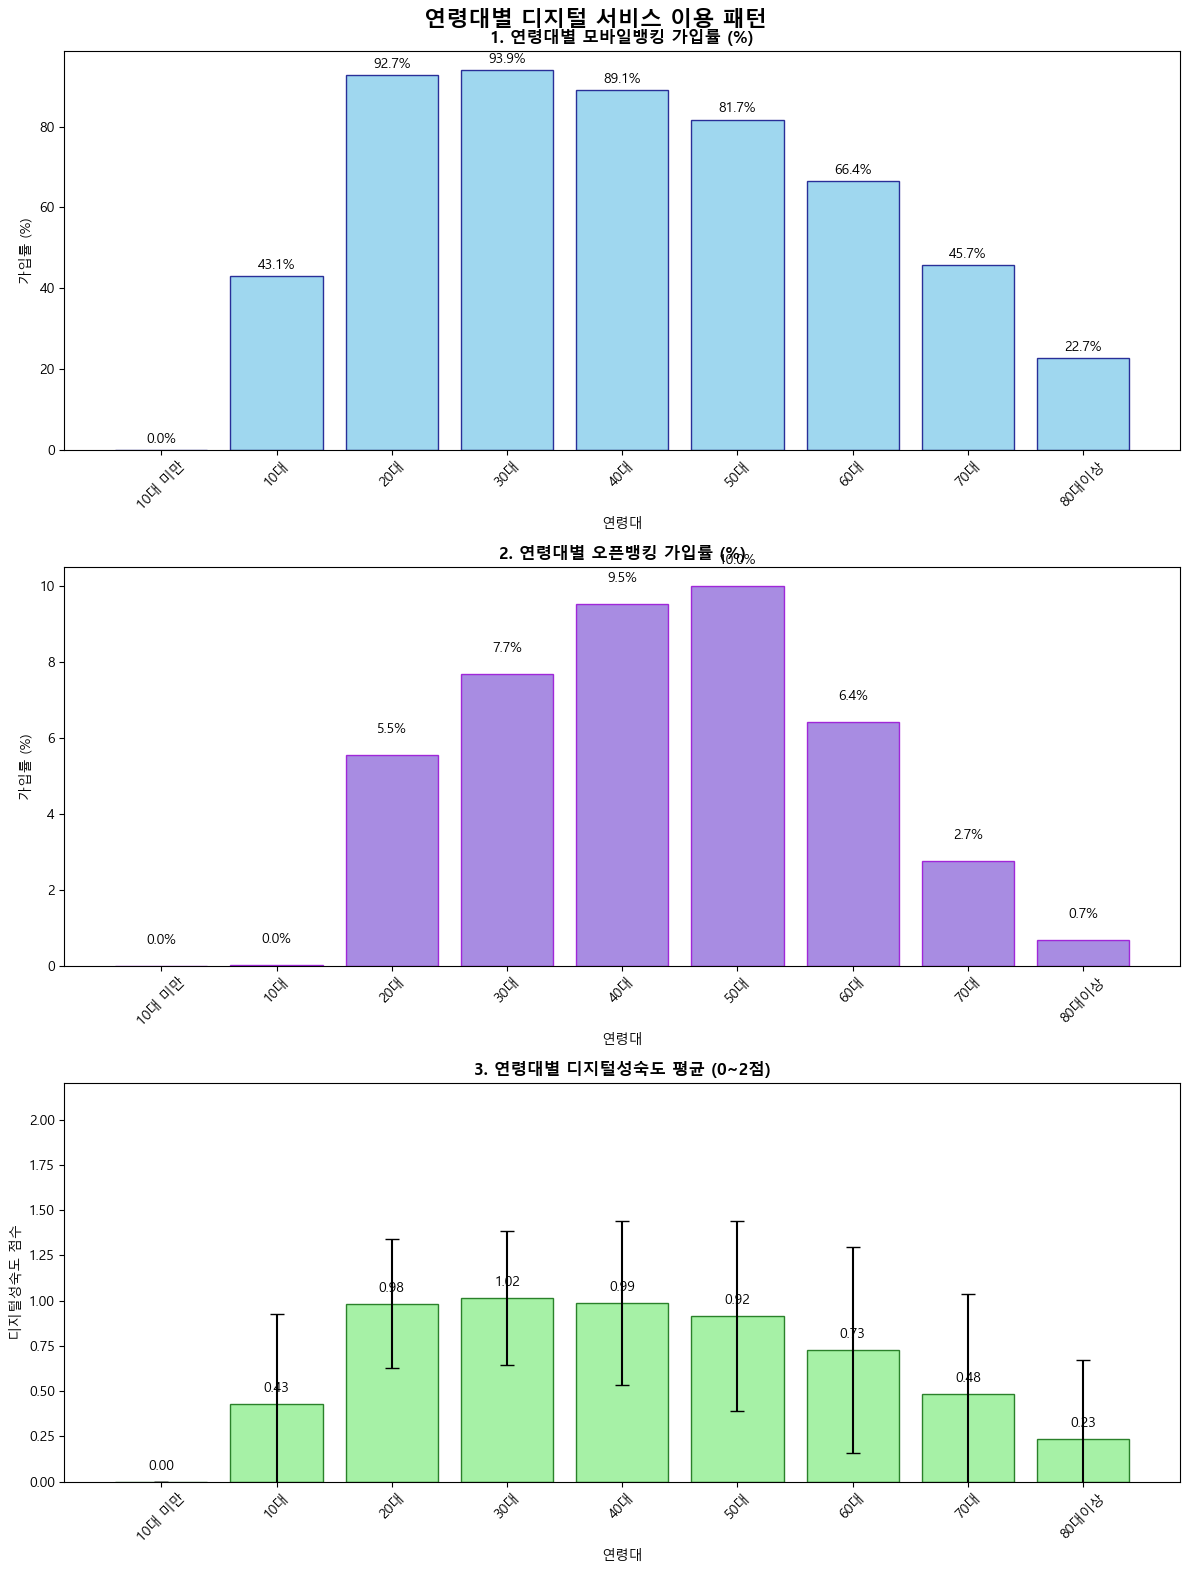

         연령대별 디지털 서비스 이용 현황

📊 10대 미만:
  모바일뱅킹 가입률: 0.0%
  오픈뱅킹 가입률: 0.0%
  디지털성숙도: 0.00점 (±0.00)

📊 10대:
  모바일뱅킹 가입률: 43.1%
  오픈뱅킹 가입률: 0.0%
  디지털성숙도: 0.43점 (±0.50)

📊 20대:
  모바일뱅킹 가입률: 92.7%
  오픈뱅킹 가입률: 5.5%
  디지털성숙도: 0.98점 (±0.36)

📊 30대:
  모바일뱅킹 가입률: 93.9%
  오픈뱅킹 가입률: 7.7%
  디지털성숙도: 1.02점 (±0.37)

📊 40대:
  모바일뱅킹 가입률: 89.1%
  오픈뱅킹 가입률: 9.5%
  디지털성숙도: 0.99점 (±0.45)

📊 50대:
  모바일뱅킹 가입률: 81.7%
  오픈뱅킹 가입률: 10.0%
  디지털성숙도: 0.92점 (±0.52)

📊 60대:
  모바일뱅킹 가입률: 66.4%
  오픈뱅킹 가입률: 6.4%
  디지털성숙도: 0.73점 (±0.57)

📊 70대:
  모바일뱅킹 가입률: 45.7%
  오픈뱅킹 가입률: 2.7%
  디지털성숙도: 0.48점 (±0.55)

📊 80대이상:
  모바일뱅킹 가입률: 22.7%
  오픈뱅킹 가입률: 0.7%
  디지털성숙도: 0.23점 (±0.44)

🎯 주요 패턴 분석:
• 모바일뱅킹 최고 가입률: 30대 (93.9%)
• 오픈뱅킹 최고 가입률: 50대 (10.0%)
• 디지털성숙도 최고: 30대 (1.02점)
• 연령대간 디지털성숙도 격차: 1.02점


In [21]:
def analyze_age_digital_patterns(df):
    """
    연령대별 디지털 서비스 이용 패턴 분석
    - 모바일뱅킹 가입률 (소문자 'y' 처리)
    - 오픈뱅킹 가입률 (소문자 'y' 처리)
    - 디지털성숙도 (0~2점)
    """
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 소문자 'y' 처리
    df['모바일뱅킹_등록'] = (df['모바일뱅킹 등록 여부'] == 'y').astype(int)
    df['오픈뱅킹_가입'] = (df['오픈뱅킹 가입 여부'] == 'y').astype(int)
    df['디지털성숙도'] = df['모바일뱅킹_등록'] + df['오픈뱅킹_가입']
    
    # 연령대별 집계
    mobile_rate = df.groupby('연령대')['모바일뱅킹_등록'].mean() * 100
    open_rate = df.groupby('연령대')['오픈뱅킹_가입'].mean() * 100
    digital_maturity = df.groupby('연령대')['디지털성숙도'].agg(['mean', 'std'])
    
    # 연령대 순서 정렬 (20대부터 70대까지)
    age_order = ['10대 미만', '10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대이상']
    mobile_rate = mobile_rate.reindex(age_order, fill_value=0)
    open_rate = open_rate.reindex(age_order, fill_value=0)
    digital_maturity = digital_maturity.reindex(age_order, fill_value=0)
    
    # 그래프 생성
    fig, axes = plt.subplots(3, 1, figsize=(12, 16))
    fig.suptitle('연령대별 디지털 서비스 이용 패턴', fontsize=16, fontweight='bold')
    
    # 1. 모바일뱅킹 가입률
    ax1 = axes[0]
    bars1 = ax1.bar(mobile_rate.index, mobile_rate.values, 
                    color='skyblue', alpha=0.8, edgecolor='navy')
    ax1.set_title('1. 연령대별 모바일뱅킹 가입률 (%)', fontweight='bold')
    ax1.set_ylabel('가입률 (%)')
    ax1.set_xlabel('연령대')
    ax1.tick_params(axis='x', rotation=45)
    
    # 막대 위에 수치 표시
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 2. 오픈뱅킹 가입률
    ax2 = axes[1]
    bars2 = ax2.bar(open_rate.index, open_rate.values, 
                    color='mediumpurple', alpha=0.8, edgecolor='darkviolet')
    ax2.set_title('2. 연령대별 오픈뱅킹 가입률 (%)', fontweight='bold')
    ax2.set_ylabel('가입률 (%)')
    ax2.set_xlabel('연령대')
    ax2.tick_params(axis='x', rotation=45)
    
    # 막대 위에 수치 표시
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom')
    
    # 3. 디지털성숙도 (평균 + 표준편차)
    ax3 = axes[2]
    bars3 = ax3.bar(digital_maturity.index, digital_maturity['mean'], 
                    yerr=digital_maturity['std'], capsize=5,
                    color='lightgreen', alpha=0.8, edgecolor='darkgreen')
    ax3.set_title('3. 연령대별 디지털성숙도 평균 (0~2점)', fontweight='bold')
    ax3.set_ylabel('디지털성숙도 점수')
    ax3.set_xlabel('연령대')
    ax3.set_ylim(0, 2.2)
    ax3.tick_params(axis='x', rotation=45)
    
    # 막대 위에 수치 표시
    for i, bar in enumerate(bars3):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:.2f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # 수치 요약 출력
    print("=" * 60)
    print("         연령대별 디지털 서비스 이용 현황")
    print("=" * 60)
    
    for age in age_order:
        if age in mobile_rate.index:
            print(f"\n📊 {age}:")
            print(f"  모바일뱅킹 가입률: {mobile_rate[age]:.1f}%")
            print(f"  오픈뱅킹 가입률: {open_rate[age]:.1f}%")
            print(f"  디지털성숙도: {digital_maturity.loc[age, 'mean']:.2f}점 (±{digital_maturity.loc[age, 'std']:.2f})")
    
    # 패턴 분석
    print(f"\n🎯 주요 패턴 분석:")
    
    # 가장 높은 가입률 연령대
    max_mobile_age = mobile_rate.idxmax()
    max_open_age = open_rate.idxmax()
    max_digital_age = digital_maturity['mean'].idxmax()
    
    print(f"• 모바일뱅킹 최고 가입률: {max_mobile_age} ({mobile_rate[max_mobile_age]:.1f}%)")
    print(f"• 오픈뱅킹 최고 가입률: {max_open_age} ({open_rate[max_open_age]:.1f}%)")
    print(f"• 디지털성숙도 최고: {max_digital_age} ({digital_maturity.loc[max_digital_age, 'mean']:.2f}점)")
    
    # 연령대별 디지털 격차
    digital_gap = digital_maturity['mean'].max() - digital_maturity['mean'].min()
    print(f"• 연령대간 디지털성숙도 격차: {digital_gap:.2f}점")
    
    return {
        '모바일뱅킹': mobile_rate,
        '오픈뱅킹': open_rate,
        '디지털성숙도': digital_maturity
    }

# 실행
results = analyze_age_digital_patterns(df)

## 문제인식

In [22]:
def calc_complete_nonuse_ratio(df):
    """
    모든 비이자이익 상품을 전혀 이용하지 않는 고객의 비율 계산
    신용카드, 체크카드, 방카슈랑스, 펀드, 기타예금 모두 0구간인 케이스
    """
    
    # 조건: 모든 비이자이익 상품이 0구간
    condition = (
        (df['신용카드 거래액 합계'] == '0구간') &
        (df['체크카드 거래액 합계'] == '0구간') &
        (df['방카슈랑스잔액'] == '0구간') &
        (df['펀드잔액'] == '0구간') &
        (df['기타예금평잔'] == '0구간')  # 오타 수정: 기타예급평잔 → 기타예금평잔
    )
    
    total_count = len(df)
    nonuse_count = condition.sum()
    nonuse_ratio = nonuse_count / total_count * 100
    
    print("=" * 50)
    print("  비이자이익 상품 완전 미이용 고객 현황")
    print("=" * 50)
    print(f"전체 고객 수: {total_count:,}명")
    print(f"완전 미이용 고객 수: {nonuse_count:,}명")
    print(f"완전 미이용 비율: {nonuse_ratio:.2f}%")
    print("=" * 50)
    
    return nonuse_count, nonuse_ratio

# 실행
nonuse_count, nonuse_ratio = calc_complete_nonuse_ratio(df)

  비이자이익 상품 완전 미이용 고객 현황
전체 고객 수: 2,093,527명
완전 미이용 고객 수: 1,320,198명
완전 미이용 비율: 63.06%


## 군집 0 제언

In [23]:
def analyze_non_interest_potential_fixed(df):
    """기타예금 보유자 중 비이자이익 기여 가능성 분석 (수정판)"""
    
    print("=== 기타예금 보유자 비이자이익 기여 잠재력 분석 ===")
    
    # 1. 비이자수익 군집 0 (Basic) 필터링
    basic_cluster = df[df['비이자수익 군집'] == 0]
    print(f"Basic 군집(0) 총 고객 수: {len(basic_cluster):,}")
    
    # 2. 기타예금 보유자 필터링 (0구간 제외)
    basic_with_savings = basic_cluster[basic_cluster['기타예금평잔'] != '0구간']
    savings_ratio = len(basic_with_savings) / len(basic_cluster) * 100
    print(f"기타예금 보유자 수: {len(basic_with_savings):,} ({savings_ratio:.1f}%)")
    
    if len(basic_with_savings) == 0:
        print("기타예금 보유자가 없습니다.")
        return {}
    
    # 3. 입출금식예금 보유 비율 (거래 활성도)
    checking_holders = basic_with_savings[basic_with_savings['입출금식예금평잔'] != '0구간']
    checking_ratio = len(checking_holders) / len(basic_with_savings) * 100
    print(f"입출금식예금 보유 비율: {checking_ratio:.1f}%")
    
    # 4. 높은 입출금 거래량 (3구간 이상)
    high_checking = basic_with_savings[basic_with_savings['입출금식예금평잔'].isin(['3구간', '4구간', '5구간', '6구간', '7구간', '8구간', '9구간'])]
    high_checking_ratio = len(high_checking) / len(basic_with_savings) * 100
    print(f"높은 입출금 거래액 보유자: {high_checking_ratio:.1f}%")
    
    # 5. 경제활동 연령대 (30-50대)
    active_age = basic_with_savings[basic_with_savings['연령대'].isin(['30대', '40대', '50대'])]
    age_ratio = len(active_age) / len(basic_with_savings) * 100
    print(f"경제활동 활발 연령대 (30-50대): {age_ratio:.1f}%")
    
    # 6. 급여이체 등록자 (안정 소득)
    salary_transfer = basic_with_savings[basic_with_savings['급여이체 등록 여부'] == 1]
    salary_ratio = len(salary_transfer) / len(basic_with_savings) * 100
    print(f"급여이체 등록자 비율: {salary_ratio:.1f}%")
    
    # 7. 모바일뱅킹 등록자 (디지털 준비도)
    mobile_banking = basic_with_savings[basic_with_savings['모바일뱅킹 등록 여부'] == 1]
    mobile_ratio = len(mobile_banking) / len(basic_with_savings) * 100
    print(f"모바일뱅킹 등록자 비율: {mobile_ratio:.1f}%")
    
    # 8. 복합 조건 (고잠재력 고객)
    high_potential = basic_with_savings[
        (basic_with_savings['입출금식예금평잔'].isin(['2구간', '3구간', '4구간', '5구간', '6구간', '7구간', '8구간', '9구간'])) &
        (basic_with_savings['연령대'].isin(['30대', '40대', '50대']))
    ]
    potential_ratio = len(high_potential) / len(basic_with_savings) * 100
    print(f"고잠재력 고객 (입출금 활발 + 경제활동 연령): {potential_ratio:.1f}%")
    
    # 9. 결과 요약
    print(f"\n=== 전략 근거 요약 ===")
    print(f"• 기타예금 보유자: {len(basic_with_savings):,}명 (Basic 군집의 {savings_ratio:.1f}%)")
    print(f"• 입출금 거래 활발: {high_checking_ratio:.1f}% → 수수료 수익 기여")
    print(f"• 급여이체 등록: {salary_ratio:.1f}% → 안정 소득원 보유")
    print(f"• 고잠재력 타겟: {potential_ratio:.1f}% → 우선 마케팅 대상")
    
    return {
        '기타예금 보유자 수': len(basic_with_savings),
        '기타예금 보유 비율': savings_ratio,
        '입출금 보유 비율': checking_ratio,
        '높은 거래액 비율': high_checking_ratio,
        '경제활동 연령 비율': age_ratio,
        '급여이체 비율': salary_ratio,
        '모바일뱅킹 비율': mobile_ratio,
        '고잠재력 비율': potential_ratio
    }

# 사용법
results = analyze_non_interest_potential_fixed(df)

=== 기타예금 보유자 비이자이익 기여 잠재력 분석 ===
Basic 군집(0) 총 고객 수: 1,428,342
기타예금 보유자 수: 108,144 (7.6%)
입출금식예금 보유 비율: 90.0%
높은 입출금 거래액 보유자: 64.4%
경제활동 활발 연령대 (30-50대): 50.7%
급여이체 등록자 비율: 0.0%
모바일뱅킹 등록자 비율: 0.0%
고잠재력 고객 (입출금 활발 + 경제활동 연령): 36.6%

=== 전략 근거 요약 ===
• 기타예금 보유자: 108,144명 (Basic 군집의 7.6%)
• 입출금 거래 활발: 64.4% → 수수료 수익 기여
• 급여이체 등록: 0.0% → 안정 소득원 보유
• 고잠재력 타겟: 36.6% → 우선 마케팅 대상


In [25]:
import pandas as pd

def analyze_non_savings_potential_fixed(df):
    """기타예금 미보유자 중 비이자이익 기여 가능성 분석"""
    
    print("=" * 60)
    print("    기타예금 미보유자 비이자이익 기여 잠재력 분석")
    print("=" * 60)
    
    # 1. 비이자수익 군집 0 (Basic) 필터링
    basic_cluster = df[df['비이자수익 군집'] == 0]
    print(f"Basic 군집(0) 총 고객 수: {len(basic_cluster):,}명")
    
    # 2. 기타예금 미보유자 필터링 (0구간인 경우)
    basic_without_savings = basic_cluster[basic_cluster['기타예금평잔'] == '0구간']
    non_savings_ratio = len(basic_without_savings) / len(basic_cluster) * 100
    print(f"기타예금 미보유자 수: {len(basic_without_savings):,}명 ({non_savings_ratio:.1f}%)")
    
    if len(basic_without_savings) == 0:
        print("기타예금 미보유자가 없습니다.")
        return {}
    
    print(f"\n📊 기타예금 미보유자 상세 특성 분석")
    print("-" * 50)
    
    # 3. 입출금식예금 보유 비율 (기본적 거래 관계)
    checking_holders = basic_without_savings[basic_without_savings['입출금식예금평잔'] != '0구간']
    checking_ratio = len(checking_holders) / len(basic_without_savings) * 100
    print(f"• 입출금식예금 보유: {checking_ratio:.1f}% ({len(checking_holders):,}명)")
    
    # 4. 높은 입출금 거래량 (3구간 이상) - 잠재적 거래 활성도
    high_checking = basic_without_savings[basic_without_savings['입출금식예금평잔'].isin([
        '3구간', '4구간', '5구간', '6구간', '7구간', '8구간', '9구간'
    ])]
    high_checking_ratio = len(high_checking) / len(basic_without_savings) * 100
    print(f"• 높은 입출금 거래액: {high_checking_ratio:.1f}% ({len(high_checking):,}명)")
    
    # 5. 경제활동 연령대 (30-50대) - 성장 잠재력
    active_age = basic_without_savings[basic_without_savings['연령대'].isin(['30대', '40대', '50대'])]
    age_ratio = len(active_age) / len(basic_without_savings) * 100
    print(f"• 경제활동 연령대 (30-50대): {age_ratio:.1f}% ({len(active_age):,}명)")
    
    # 6. 급여이체 등록자 (안정적 소득원)
    salary_transfer = basic_without_savings[basic_without_savings['급여이체 등록 여부'] == 'y']
    salary_ratio = len(salary_transfer) / len(basic_without_savings) * 100
    print(f"• 급여이체 등록: {salary_ratio:.1f}% ({len(salary_transfer):,}명)")
    
    # 7. 모바일뱅킹 등록자 (디지털 준비도)
    mobile_banking = basic_without_savings[basic_without_savings['모바일뱅킹 등록 여부'] == 'y']
    mobile_ratio = len(mobile_banking) / len(basic_without_savings) * 100
    print(f"• 모바일뱅킹 등록: {mobile_ratio:.1f}% ({len(mobile_banking):,}명)")
    
    # 8. 오픈뱅킹 가입자 (혁신 서비스 수용성)
    open_banking = basic_without_savings[basic_without_savings['오픈뱅킹 가입 여부'] == 'y']
    open_ratio = len(open_banking) / len(basic_without_savings) * 100
    print(f"• 오픈뱅킹 가입: {open_ratio:.1f}% ({len(open_banking):,}명)")
    
    # 9. 디지털 성숙도 (모바일뱅킹 + 오픈뱅킹 가입자)
    digital_both = basic_without_savings[
        (basic_without_savings['모바일뱅킹 등록 여부'] == 'y') &
        (basic_without_savings['오픈뱅킹 가입 여부'] == 'y')
    ]
    digital_both_ratio = len(digital_both) / len(basic_without_savings) * 100
    print(f"• 디지털 서비스 둘 다 가입: {digital_both_ratio:.1f}% ({len(digital_both):,}명)")
    
    # 10. 적립식예금 보유자 (저축 성향)
    installment_savings = basic_without_savings[basic_without_savings['적립식예금평잔'] != '0구간']
    installment_ratio = len(installment_savings) / len(basic_without_savings) * 100
    print(f"• 적립식예금 보유: {installment_ratio:.1f}% ({len(installment_savings):,}명)")
    
    # 11. 거치식예금 보유자 (목돈 관리 능력)
    term_deposit = basic_without_savings[basic_without_savings['거치식예금평잔'] != '0구간']
    term_ratio = len(term_deposit) / len(basic_without_savings) * 100
    print(f"• 거치식예금 보유: {term_ratio:.1f}% ({len(term_deposit):,}명)")
    
    # 12. 복합 조건별 세분화
    print(f"\n🎯 잠재력별 고객 세분화")
    print("-" * 50)
    
    # 고잠재력: 입출금 활발 + 경제활동 연령 + 디지털 활용
    high_potential = basic_without_savings[
        (basic_without_savings['입출금식예금평잔'].isin(['2구간', '3구간', '4구간', '5구간', '6구간', '7구간', '8구간', '9구간'])) &
        (basic_without_savings['연령대'].isin(['30대', '40대', '50대'])) &
        (basic_without_savings['모바일뱅킹 등록 여부'] == 'y')
    ]
    high_potential_ratio = len(high_potential) / len(basic_without_savings) * 100
    print(f"• 최우선 타겟 (입출금활발+경제활동연령+모바일뱅킹): {high_potential_ratio:.1f}% ({len(high_potential):,}명)")
    
    # 중잠재력: 경제활동 연령 + 기본 거래 관계
    medium_potential = basic_without_savings[
        (basic_without_savings['연령대'].isin(['30대', '40대', '50대'])) &
        (basic_without_savings['입출금식예금평잔'] != '0구간') &
        (~basic_without_savings.index.isin(high_potential.index))  # 최우선 타겟 제외
    ]
    medium_potential_ratio = len(medium_potential) / len(basic_without_savings) * 100
    print(f"• 2차 우선 타겟 (경제활동연령+기본거래): {medium_potential_ratio:.1f}% ({len(medium_potential):,}명)")
    
    # 저잠재력: 나머지
    low_potential = len(basic_without_savings) - len(high_potential) - len(medium_potential)
    low_potential_ratio = low_potential / len(basic_without_savings) * 100
    print(f"• 장기 육성 대상 (나머지): {low_potential_ratio:.1f}% ({low_potential:,}명)")
    
    # 13. 기타예금 보유자와 비교
    basic_with_savings = basic_cluster[basic_cluster['기타예금평잔'] != '0구간']
    
    print(f"\n📈 기타예금 보유자 vs 미보유자 비교")
    print("-" * 50)
    
    # 비교 지표들
    if len(basic_with_savings) > 0:
        savings_mobile = (basic_with_savings['모바일뱅킹 등록 여부'] == 'y').mean() * 100
        savings_checking = (basic_with_savings['입출금식예금평잔'] != '0구간').mean() * 100
        savings_salary = (basic_with_savings['급여이체 등록 여부'] == 'y').mean() * 100
        
        print(f"• 모바일뱅킹 가입률: 보유자 {savings_mobile:.1f}% vs 미보유자 {mobile_ratio:.1f}% (차이: {mobile_ratio-savings_mobile:+.1f}%p)")
        print(f"• 입출금예금 보유율: 보유자 {savings_checking:.1f}% vs 미보유자 {checking_ratio:.1f}% (차이: {checking_ratio-savings_checking:+.1f}%p)")
        print(f"• 급여이체 등록률: 보유자 {savings_salary:.1f}% vs 미보유자 {salary_ratio:.1f}% (차이: {salary_ratio-savings_salary:+.1f}%p)")
    
    # 14. 전략적 시사점
    print(f"\n💡 전략적 시사점")
    print("-" * 50)
    print(f"• 전체 규모: {len(basic_without_savings):,}명 (Basic 군집의 {non_savings_ratio:.1f}%)")
    print(f"• 최우선 타겟: {len(high_potential):,}명 ({high_potential_ratio:.1f}%)")
    print(f"• 디지털 전환 여지: 모바일뱅킹 미가입자 {100-mobile_ratio:.1f}%")
    print(f"• 주거래 관계 구축 기회: 급여이체 미등록자 {100-salary_ratio:.1f}%")
    
    return {
        '기타예금 미보유자 수': len(basic_without_savings),
        '미보유자 비율': non_savings_ratio,
        '입출금 보유 비율': checking_ratio,
        '높은 거래액 비율': high_checking_ratio,
        '경제활동 연령 비율': age_ratio,
        '급여이체 비율': salary_ratio,
        '모바일뱅킹 비율': mobile_ratio,
        '오픈뱅킹 비율': open_ratio,
        '적립식예금 비율': installment_ratio,
        '거치식예금 비율': term_ratio,
        '최우선 타겟 비율': high_potential_ratio,
        '2차 타겟 비율': medium_potential_ratio,
        '장기 육성 비율': low_potential_ratio,
        '최우선 타겟 수': len(high_potential),
        '2차 타겟 수': len(medium_potential)
    }

# 사용법
results_non_savings = analyze_non_savings_potential_fixed(df)

    기타예금 미보유자 비이자이익 기여 잠재력 분석
Basic 군집(0) 총 고객 수: 1,428,342명
기타예금 미보유자 수: 1,320,198명 (92.4%)

📊 기타예금 미보유자 상세 특성 분석
--------------------------------------------------
• 입출금식예금 보유: 76.0% (1,003,171명)
• 높은 입출금 거래액: 43.2% (569,875명)
• 경제활동 연령대 (30-50대): 59.2% (781,407명)
• 급여이체 등록: 22.8% (301,255명)
• 모바일뱅킹 등록: 74.6% (984,724명)
• 오픈뱅킹 가입: 5.4% (70,780명)
• 디지털 서비스 둘 다 가입: 5.3% (70,569명)
• 적립식예금 보유: 4.8% (63,973명)
• 거치식예금 보유: 6.3% (83,765명)

🎯 잠재력별 고객 세분화
--------------------------------------------------
• 최우선 타겟 (입출금활발+경제활동연령+모바일뱅킹): 22.4% (296,254명)
• 2차 우선 타겟 (경제활동연령+기본거래): 20.1% (265,170명)
• 장기 육성 대상 (나머지): 57.5% (758,774명)

📈 기타예금 보유자 vs 미보유자 비교
--------------------------------------------------
• 모바일뱅킹 가입률: 보유자 79.0% vs 미보유자 74.6% (차이: -4.4%p)
• 입출금예금 보유율: 보유자 90.0% vs 미보유자 76.0% (차이: -14.0%p)
• 급여이체 등록률: 보유자 42.5% vs 미보유자 22.8% (차이: -19.7%p)

💡 전략적 시사점
--------------------------------------------------
• 전체 규모: 1,320,198명 (Basic 군집의 92.4%)
• 최우선 타겟: 296,254명 (22.4%)
• 디지털 전환 여지: 모바일뱅킹 

## VIP

In [26]:
def analyze_avg_product_usage_by_cluster(df):
    """
    군집별 비이자수익 상품(방카슈랑스, 펀드, 신용카드, 체크카드) 
    평균 사용개수 분석
    """
    
    print("=" * 60)
    print("        군집별 평균 상품 사용개수 분석")
    print("=" * 60)
    
    # 분석 대상 상품
    products = {
        '방카슈랑스잔액': '방카슈랑스',
        '펀드잔액': '펀드',
        '신용카드 거래액 합계': '신용카드',
        '체크카드 거래액 합계': '체크카드'
    }
    
    # 각 상품별 사용여부 계산 (0구간 아니면 사용)
    for col, name in products.items():
        df[f'{name}_사용'] = (df[col] != '0구간').astype(int)
    
    # 총 상품 사용개수 계산
    usage_cols = [f'{name}_사용' for name in products.values()]
    df['총_상품_사용개수'] = df[usage_cols].sum(axis=1)
    
    # 군집별 평균 계산
    cluster_avg = df.groupby('비이자수익 군집')['총_상품_사용개수'].agg(['mean', 'std']).round(2)
    
    print("📊 군집별 평균 상품 사용개수:")
    print("-" * 40)
    for cluster in sorted(df['비이자수익 군집'].unique()):
        mean_val = cluster_avg.loc[cluster, 'mean']
        std_val = cluster_avg.loc[cluster, 'std']
        print(f"군집 {cluster}: {mean_val:.2f}개 (±{std_val:.2f})")
    
    # 군집별 상품별 사용률
    print(f"\n📈 군집별 개별 상품 사용률:")
    print("-" * 50)
    print(f"{'군집':<5} {'방카슈랑스':<10} {'펀드':<8} {'신용카드':<10} {'체크카드':<8}")
    print("-" * 50)
    
    for cluster in sorted(df['비이자수익 군집'].unique()):
        cluster_data = df[df['비이자수익 군집'] == cluster]
        rates = []
        for name in products.values():
            rate = cluster_data[f'{name}_사용'].mean() * 100
            rates.append(f"{rate:.1f}%")
        
        print(f"{cluster:<5} {rates[0]:<10} {rates[1]:<8} {rates[2]:<10} {rates[3]:<8}")
    
    # 상품 조합 분석
    print(f"\n🔍 군집별 상품 사용개수 분포:")
    print("-" * 40)
    
    for cluster in sorted(df['비이자수익 군집'].unique()):
        cluster_data = df[df['비이자수익 군집'] == cluster]
        count_dist = cluster_data['총_상품_사용개수'].value_counts(normalize=True).sort_index() * 100
        
        print(f"\n군집 {cluster}:")
        for count, pct in count_dist.items():
            print(f"  {count}개 사용: {pct:.1f}%")
    
    return cluster_avg
